# Next Word Prediction Using LSTM

## Project Overview

This project implements a **Next Word Prediction system using a Long Short-Term Memory (LSTM) neural network**.

The objective is to train a language model that learns the patterns, vocabulary, and word relationships present in Shakespeare's **Hamlet** and predicts the most probable next word given a sequence of previous words.

### Project Workflow

1. **Data Collection**
   - Load Shakespeare's *Hamlet* using the NLTK Gutenberg corpus.

2. **Text Preprocessing**
   - Convert text to lowercase.
   - Clean and normalize the text.
   - Split the corpus into training, validation, and testing portions.

3. **Tokenization**
   - Convert words into integer token IDs.
   - Build the vocabulary using the training corpus.

4. **Sequence Generation**
   - Create fixed-length input sequences.
   - Use the next word as the prediction target.

5. **Model Building**
   - Use an Embedding layer to learn word representations.
   - Use an LSTM layer to learn sequential dependencies.
   - Use a Dense + Softmax layer for next-word prediction.

6. **Model Training**
   - Train using the training dataset.
   - Monitor validation loss.
   - Use EarlyStopping and learning-rate reduction to improve generalization.

7. **Model Evaluation**
   - Evaluate the model on unseen test data.
   - Measure:
     - Accuracy
     - Top-5 Accuracy
     - Loss

8. **Text Generation**
   - Provide a starting sentence.
   - Predict the next word.
   - Generate multiple words sequentially.

## Important Design Decisions

Unlike the previous version, this project will:

- Split the **original text before generating sequences**.
- Use a fixed context length instead of the maximum sequence length.
- Fit the tokenizer only on the training corpus.
- Avoid one-hot encoding when it is unnecessary.
- Use regularization to reduce overfitting.
- Use callbacks for better training.
- Evaluate the model on genuinely unseen text.


In [1]:
# ============================================================
# CELL 2: IMPORT LIBRARIES & SET RANDOM SEEDS
# ============================================================

import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from nltk.corpus import gutenberg

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.metrics import SparseTopKCategoricalAccuracy


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)
print("Random Seed:", SEED)

TensorFlow Version: 2.20.0
NumPy Version: 2.1.3
Random Seed: 42


In [2]:
# ============================================================
# CELL 3: LOAD HAMLET DATASET
# ============================================================

# Download the Gutenberg corpus if it is not already available
import nltk

nltk.download("gutenberg", quiet=True)


# Load Shakespeare's Hamlet
raw_text = gutenberg.raw("shakespeare-hamlet.txt")


# Convert text to lowercase
raw_text = raw_text.lower()


# Display basic information
print("Dataset loaded successfully!")
print("Total characters:", len(raw_text))
print("\nFirst 500 characters:\n")
print(raw_text[:500])

Dataset loaded successfully!
Total characters: 162881

First 500 characters:

[the tragedie of hamlet by william shakespeare 1599]


actus primus. scoena prima.

enter barnardo and francisco two centinels.

  barnardo. who's there?
  fran. nay answer me: stand & vnfold
your selfe

   bar. long liue the king

   fran. barnardo?
  bar. he

   fran. you come most carefully vpon your houre

   bar. 'tis now strook twelue, get thee to bed francisco

   fran. for this releefe much thankes: 'tis bitter cold,
and i am sicke at heart

   barn. haue you had quiet guard?
  fran. not


In [3]:
# ============================================================
# CELL 4: DATASET INSPECTION & BASIC STATISTICS
# ============================================================

# Number of characters
total_characters = len(raw_text)

# Number of words
total_words_in_corpus = len(raw_text.split())

# Number of lines
total_lines = len(raw_text.splitlines())

# Unique characters
unique_characters = len(set(raw_text))

# Display statistics
print("========== HAMLET DATASET STATISTICS ==========")
print(f"Total Characters : {total_characters:,}")
print(f"Total Words      : {total_words_in_corpus:,}")
print(f"Total Lines      : {total_lines:,}")
print(f"Unique Characters: {unique_characters}")
print("===============================================")


# Display a few lines from the corpus
print("\nFirst 10 Lines:\n")

for i, line in enumerate(raw_text.splitlines()[:10], start=1):
    print(f"{i}: {line}")

========== HAMLET DATASET STATISTICS ==========
Total Characters : 162,881
Total Words      : 29,605
Total Lines      : 4,922
Unique Characters: 44

First 10 Lines:

1: [the tragedie of hamlet by william shakespeare 1599]
2: 
3: 
4: actus primus. scoena prima.
5: 
6: enter barnardo and francisco two centinels.
7: 
8:   barnardo. who's there?
9:   fran. nay answer me: stand & vnfold
10: your selfe


In [4]:
# ============================================================
# CELL 5: TEXT CLEANING & NORMALIZATION
# ============================================================

import re


# ------------------------------------------------------------
# 1. Remove Gutenberg metadata/header
# ------------------------------------------------------------

text = re.sub(
    r"\[the tragedie of hamlet by william shakespeare 1599\]",
    "",
    raw_text,
    flags=re.IGNORECASE
)


# ------------------------------------------------------------
# 2. Normalize line breaks
# ------------------------------------------------------------

text = text.replace("\r\n", "\n")
text = text.replace("\r", "\n")


# ------------------------------------------------------------
# 3. Remove excessive whitespace
# ------------------------------------------------------------

# Replace multiple spaces/tabs with a single space
text = re.sub(r"[ \t]+", " ", text)


# ------------------------------------------------------------
# 4. Normalize multiple blank lines
# ------------------------------------------------------------

text = re.sub(r"\n{3,}", "\n\n", text)


# ------------------------------------------------------------
# 5. Remove leading/trailing whitespace
# ------------------------------------------------------------

text = text.strip()


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("Text cleaning completed successfully!")

print("\nOriginal characters :", len(raw_text))
print("Cleaned characters  :", len(text))

print("\nFirst 500 characters after cleaning:\n")
print(text[:500])

Text cleaning completed successfully!

Original characters : 162881
Cleaned characters  : 160994

First 500 characters after cleaning:

actus primus. scoena prima.

enter barnardo and francisco two centinels.

 barnardo. who's there?
 fran. nay answer me: stand & vnfold
your selfe

 bar. long liue the king

 fran. barnardo?
 bar. he

 fran. you come most carefully vpon your houre

 bar. 'tis now strook twelue, get thee to bed francisco

 fran. for this releefe much thankes: 'tis bitter cold,
and i am sicke at heart

 barn. haue you had quiet guard?
 fran. not a mouse stirring

 barn. well, goodnight. if you do meet horatio and
m


In [5]:
# ============================================================
# CELL 6: TRAIN / VALIDATION / TEST TEXT SPLIT
# ============================================================

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10


# ------------------------------------------------------------
# Verify split ratios
# ------------------------------------------------------------

assert TRAIN_RATIO + VAL_RATIO + TEST_RATIO == 1.0


# ------------------------------------------------------------
# Calculate split positions
# ------------------------------------------------------------

total_length = len(text)

train_end = int(total_length * TRAIN_RATIO)
val_end = train_end + int(total_length * VAL_RATIO)


# ------------------------------------------------------------
# Split the RAW TEXT
# ------------------------------------------------------------

train_text = text[:train_end]

val_text = text[train_end:val_end]

test_text = text[val_end:]


# ------------------------------------------------------------
# Display statistics
# ------------------------------------------------------------

print("========== TEXT SPLIT ==========")

print(f"Total characters : {len(text):,}")
print(f"Training         : {len(train_text):,}")
print(f"Validation       : {len(val_text):,}")
print(f"Testing          : {len(test_text):,}")

print("\n========== PERCENTAGES ==========")

print(f"Training   : {len(train_text) / len(text) * 100:.2f}%")
print(f"Validation : {len(val_text) / len(text) * 100:.2f}%")
print(f"Testing    : {len(test_text) / len(text) * 100:.2f}%")

========== TEXT SPLIT ==========
Total characters : 160,994
Training         : 128,795
Validation       : 16,099
Testing          : 16,100

========== PERCENTAGES ==========
Training   : 80.00%
Validation : 10.00%
Testing    : 10.00%


In [6]:
# ============================================================
# CELL 7: TOKENIZATION
# ============================================================

# Create tokenizer
tokenizer = Tokenizer(
    oov_token="<OOV>"
)


# ------------------------------------------------------------
# Fit tokenizer ONLY on training text
# ------------------------------------------------------------

tokenizer.fit_on_texts([train_text])


# ------------------------------------------------------------
# Get vocabulary size
# ------------------------------------------------------------

total_words = len(tokenizer.word_index) + 1


# ------------------------------------------------------------
# Convert text into integer sequences
# ------------------------------------------------------------

train_sequences = tokenizer.texts_to_sequences([train_text])[0]

val_sequences = tokenizer.texts_to_sequences([val_text])[0]

test_sequences = tokenizer.texts_to_sequences([test_text])[0]


# ------------------------------------------------------------
# Display statistics
# ------------------------------------------------------------

print("========== TOKENIZATION RESULTS ==========")

print(f"Vocabulary Size       : {total_words:,}")

print(f"Training tokens       : {len(train_sequences):,}")
print(f"Validation tokens     : {len(val_sequences):,}")
print(f"Testing tokens        : {len(test_sequences):,}")


# ------------------------------------------------------------
# Display sample word-to-index mappings
# ------------------------------------------------------------

print("\n========== SAMPLE WORD → INDEX ==========")

sample_words = [
    "the",
    "king",
    "hamlet",
    "love",
    "death"
]

for word in sample_words:
    index = tokenizer.word_index.get(word, None)
    print(f"{word:10s} → {index}")


# ------------------------------------------------------------
# Display first 20 tokenized words
# ------------------------------------------------------------

print("\n========== FIRST 20 TOKEN IDs ==========")

print(train_sequences[:20])

========== TOKENIZATION RESULTS ==========
Vocabulary Size       : 4,121
Training tokens       : 23,750
Validation tokens     : 2,982
Testing tokens        : 2,960

========== SAMPLE WORD → INDEX ==========
the        → 2
king       → 30
hamlet     → 50
love       → None
death      → 142

========== FIRST 20 TOKEN IDs ==========
[993, 1578, 1579, 1580, 48, 359, 3, 994, 164, 1581, 359, 995, 65, 360, 165, 361, 23, 289, 713, 17]


In [7]:
# ============================================================
# CELL 8: FIXED-LENGTH SEQUENCE GENERATION
# ============================================================

SEQUENCE_LENGTH = 20


# ------------------------------------------------------------
# Function to create input sequences and targets
# ------------------------------------------------------------

def create_sequences(token_sequence, sequence_length):
    """
    Create fixed-length input sequences for next-word prediction.

    Example:
        sequence_length = 5

        [10, 20, 30, 40, 50, 60]

        Input  → [10, 20, 30, 40]
        Target → 50

        Input  → [20, 30, 40, 50]
        Target → 60
    """

    X = []
    y = []

    for i in range(sequence_length, len(token_sequence)):
        X.append(
            token_sequence[i - sequence_length:i]
        )

        y.append(
            token_sequence[i]
        )

    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32)


# ------------------------------------------------------------
# Create sequences for each dataset separately
# ------------------------------------------------------------

X_train, y_train = create_sequences(
    train_sequences,
    SEQUENCE_LENGTH
)

X_val, y_val = create_sequences(
    val_sequences,
    SEQUENCE_LENGTH
)

X_test, y_test = create_sequences(
    test_sequences,
    SEQUENCE_LENGTH
)


# ------------------------------------------------------------
# Display dataset shapes
# ------------------------------------------------------------

print("========== SEQUENCE DATASET SHAPES ==========")

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")

print(f"X_val   : {X_val.shape}")
print(f"y_val   : {y_val.shape}")

print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")


# ------------------------------------------------------------
# Display one example
# ------------------------------------------------------------

print("\n========== SAMPLE SEQUENCE ==========")

print("Input token IDs:")
print(X_train[0])

print("\nTarget token ID:")
print(y_train[0])


# ------------------------------------------------------------
# Convert token IDs back to words
# ------------------------------------------------------------

index_to_word = {
    index: word
    for word, index in tokenizer.word_index.items()
}


print("\n========== SAMPLE SEQUENCE AS WORDS ==========")

input_words = [
    index_to_word.get(token_id, "<OOV>")
    for token_id in X_train[0]
]

target_word = index_to_word.get(
    y_train[0],
    "<OOV>"
)

print("Input :", " ".join(input_words))
print("Target:", target_word)

========== SEQUENCE DATASET SHAPES ==========
X_train : (23730, 20)
y_train : (23730,)
X_val   : (2962, 20)
y_val   : (2962,)
X_test  : (2940, 20)
y_test  : (2940,)

========== SAMPLE SEQUENCE ==========
Input token IDs:
[ 993 1578 1579 1580   48  359    3  994  164 1581  359  995   65  360
  165  361   23  289  713   17]

Target token ID:
63

========== SAMPLE SEQUENCE AS WORDS ==========
Input : actus primus scoena prima enter barnardo and francisco two centinels barnardo who's there fran nay answer me stand vnfold your
Target: selfe


In [8]:
# ============================================================
# CELL 9: VERIFY SEQUENCE GENERATION
# ============================================================

print("========== SEQUENCE SANITY CHECK ==========\n")


# ------------------------------------------------------------
# Check the first 3 sequences
# ------------------------------------------------------------

for i in range(3):

    input_words = [
        index_to_word.get(token_id, "<OOV>")
        for token_id in X_train[i]
    ]

    target_word = index_to_word.get(
        y_train[i],
        "<OOV>"
    )

    print(f"Sequence {i + 1}")
    print("-" * 60)

    print("Input :")
    print(" ".join(input_words))

    print("\nTarget:")
    print(target_word)

    print("\nInput Length:", len(X_train[i]))
    print("=" * 60)

========== SEQUENCE SANITY CHECK ==========

Sequence 1
------------------------------------------------------------
Input :
actus primus scoena prima enter barnardo and francisco two centinels barnardo who's there fran nay answer me stand vnfold your

Target:
selfe

Input Length: 20
Sequence 2
------------------------------------------------------------
Input :
primus scoena prima enter barnardo and francisco two centinels barnardo who's there fran nay answer me stand vnfold your selfe

Target:
bar

Input Length: 20
Sequence 3
------------------------------------------------------------
Input :
scoena prima enter barnardo and francisco two centinels barnardo who's there fran nay answer me stand vnfold your selfe bar

Target:
long

Input Length: 20


In [9]:
# ============================================================
# CELL 10: BUILD BASELINE LSTM MODEL
# ============================================================

model = Sequential([

    # --------------------------------------------------------
    # Input Layer
    # --------------------------------------------------------
    Input(shape=(SEQUENCE_LENGTH,)),


    # --------------------------------------------------------
    # Embedding Layer
    # --------------------------------------------------------
    # Converts word IDs into dense vector representations.
    # --------------------------------------------------------
    Embedding(
        input_dim=total_words,
        output_dim=64
    ),


    # --------------------------------------------------------
    # LSTM Layer
    # --------------------------------------------------------
    # Learns sequential dependencies between words.
    # --------------------------------------------------------
    LSTM(
        64,
        dropout=0.2,
        recurrent_dropout=0.2
    ),


    # --------------------------------------------------------
    # Dropout Layer
    # --------------------------------------------------------
    # Helps reduce overfitting.
    # --------------------------------------------------------
    Dropout(0.4),


    # --------------------------------------------------------
    # Output Layer
    # --------------------------------------------------------
    # Predicts probability for every word in the vocabulary.
    # --------------------------------------------------------
    Dense(
        total_words,
        activation="softmax"
    )
])


# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy",
        SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)


# ============================================================
# DISPLAY MODEL SUMMARY
# ============================================================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 64)         │       263,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4121)           │       267,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 564,633 (2.15 MB)

 Trainable params: 564,633 (2.15 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ============================================================
# CELL 11: TRAINING CALLBACKS
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)


# ------------------------------------------------------------
# 1. Early Stopping
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)


# ------------------------------------------------------------
# 2. Reduce Learning Rate
# ------------------------------------------------------------

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)


# ------------------------------------------------------------
# 3. Save Best Model
# ------------------------------------------------------------

model_checkpoint = ModelCheckpoint(
    "best_lstm_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


# ------------------------------------------------------------
# Combine callbacks
# ------------------------------------------------------------

callbacks = [
    early_stopping,
    reduce_lr,
    model_checkpoint
]


print("Training callbacks configured successfully!")

print("\nCallbacks:")
print("1. EarlyStopping")
print("2. ReduceLROnPlateau")
print("3. ModelCheckpoint")

Training callbacks configured successfully!

Callbacks:
1. EarlyStopping
2. ReduceLROnPlateau
3. ModelCheckpoint


In [11]:
# ============================================================
# CELL 12: TRAIN THE BASELINE LSTM MODEL
# ============================================================

EPOCHS = 30
BATCH_SIZE = 64


history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,

    callbacks=callbacks,

    verbose=1
)


print("\nTraining completed successfully!")

Epoch 1/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.0244 - loss: 7.1914 - top_5_accuracy: 0.1087
Epoch 1: val_loss improved from None to 6.80617, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
371/371 ━━━━━━━━━━━━━━━━━━━━ 35s 77ms/step - accuracy: 0.0296 - loss: 6.7902 - top_5_accuracy: 0.1203 - val_accuracy: 0.0327 - val_loss: 6.8062 - val_top_5_accuracy: 0.1074 - learning_rate: 0.0010
Epoch 2/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.0313 - loss: 6.4054 - top_5_accuracy: 0.1288
Epoch 2: val_loss did not improve from 6.80617
371/371 ━━━━━━━━━━━━━━━━━━━━ 27s 74ms/step - accuracy: 0.0322 - loss: 6.4264 - top_5_accuracy: 0.1286 - val_accuracy: 0.0327 - val_loss: 6.9152 - val_top_5_accuracy: 0.1020 - learning_rate: 0.0010
Epoch 3/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.0332 - loss: 6.3537 - top_5_accuracy: 0.1305
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Ep

In [12]:
# ============================================================
# CELL 13: ANALYZE OOV TOKENS AND VOCABULARY COVERAGE
# ============================================================

# OOV token ID
oov_token_id = tokenizer.word_index["<OOV>"]


# ------------------------------------------------------------
# Count OOV tokens
# ------------------------------------------------------------

train_oov_count = np.sum(
    np.array(train_sequences) == oov_token_id
)

val_oov_count = np.sum(
    np.array(val_sequences) == oov_token_id
)

test_oov_count = np.sum(
    np.array(test_sequences) == oov_token_id
)


# ------------------------------------------------------------
# Calculate OOV percentages
# ------------------------------------------------------------

train_oov_percentage = (
    train_oov_count / len(train_sequences)
) * 100

val_oov_percentage = (
    val_oov_count / len(val_sequences)
) * 100

test_oov_percentage = (
    test_oov_count / len(test_sequences)
) * 100


# ------------------------------------------------------------
# Display OOV statistics
# ------------------------------------------------------------

print("========== OOV ANALYSIS ==========")

print(
    f"Training OOV   : {train_oov_count:,} "
    f"({train_oov_percentage:.2f}%)"
)

print(
    f"Validation OOV : {val_oov_count:,} "
    f"({val_oov_percentage:.2f}%)"
)

print(
    f"Testing OOV    : {test_oov_count:,} "
    f"({test_oov_percentage:.2f}%)"
)


# ------------------------------------------------------------
# Unique vocabulary in each raw text split
# ------------------------------------------------------------

train_unique_words = set(train_text.split())
val_unique_words = set(val_text.split())
test_unique_words = set(test_text.split())


print("\n========== UNIQUE WORD ANALYSIS ==========")

print(f"Training unique words   : {len(train_unique_words):,}")
print(f"Validation unique words : {len(val_unique_words):,}")
print(f"Testing unique words    : {len(test_unique_words):,}")


# ------------------------------------------------------------
# Words unseen during training
# ------------------------------------------------------------

val_unseen_words = val_unique_words - train_unique_words
test_unseen_words = test_unique_words - train_unique_words


print("\n========== UNSEEN WORDS ==========")

print(
    f"Validation unseen words : "
    f"{len(val_unseen_words):,}"
)

print(
    f"Testing unseen words    : "
    f"{len(test_unseen_words):,}"
)


# ------------------------------------------------------------
# Display examples
# ------------------------------------------------------------

print("\nSample validation unseen words:")

print(
    list(sorted(val_unseen_words))[:20]
)

print("\nSample testing unseen words:")

print(
    list(sorted(test_unseen_words))[:20]
)

========== OOV ANALYSIS ==========
Training OOV   : 0 (0.00%)
Validation OOV : 471 (15.79%)
Testing OOV    : 412 (13.92%)

========== UNIQUE WORD ANALYSIS ==========
Training unique words   : 5,678
Validation unique words : 1,198
Testing unique words    : 1,174

========== UNSEEN WORDS ==========
Validation unseen words : 555
Testing unseen words    : 497

Sample validation unseen words:
['(churlish', '(sweet', '(whereto', '?', 'abhorred', 'absolute', 'adaies,', 'adam', 'adams', 'adue', 'ake', 'akers', 'alexander', 'alexander,', 'allowed', 'ancient', 'annoint', 'another?', 'anothers', 'answerest']

Sample testing unseen words:
["'tweene", '(things', 'a-while.', 'abilitie', 'about.', 'absent', 'accidentall', 'acte:', 'acts,', 'adiew,', 'afarre', 'affaires', "affear'd", 'allowed', 'aloofe,', 'amb.', 'ambassador,', 'amis.', 'amities,', 'angle']


In [13]:
# ============================================================
# CELL 14: FINAL TOKENIZATION FOR VERSION 2
# ============================================================

# Create a fresh tokenizer
tokenizer = Tokenizer(
    oov_token="<OOV>"
)


# ------------------------------------------------------------
# Fit tokenizer on the COMPLETE corpus
# ------------------------------------------------------------
# IMPORTANT:
# We are only learning the vocabulary here.
# We are NOT using validation/test sequences for training.
# ------------------------------------------------------------

tokenizer.fit_on_texts([text])


# ------------------------------------------------------------
# Vocabulary size
# ------------------------------------------------------------

total_words = len(tokenizer.word_index) + 1


# ------------------------------------------------------------
# Convert each split into token IDs
# ------------------------------------------------------------

train_sequences = tokenizer.texts_to_sequences(
    [train_text]
)[0]

val_sequences = tokenizer.texts_to_sequences(
    [val_text]
)[0]

test_sequences = tokenizer.texts_to_sequences(
    [test_text]
)[0]


# ------------------------------------------------------------
# Create reverse mapping
# ------------------------------------------------------------

index_to_word = {
    index: word
    for word, index in tokenizer.word_index.items()
}


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("========== FINAL TOKENIZATION ==========")

print(f"Vocabulary Size   : {total_words:,}")

print(f"Training tokens   : {len(train_sequences):,}")
print(f"Validation tokens : {len(val_sequences):,}")
print(f"Testing tokens    : {len(test_sequences):,}")


# ------------------------------------------------------------
# Check sample words
# ------------------------------------------------------------

print("\n========== SAMPLE WORD → INDEX ==========")

sample_words = [
    "the",
    "king",
    "hamlet",
    "love",
    "death",
    "shakespeare"
]

for word in sample_words:

    index = tokenizer.word_index.get(
        word,
        None
    )

    print(f"{word:12s} → {index}")

========== FINAL TOKENIZATION ==========
Vocabulary Size   : 4,816
Training tokens   : 23,750
Validation tokens : 2,982
Testing tokens    : 2,960

========== SAMPLE WORD → INDEX ==========
the          → 2
king         → 31
hamlet       → 46
love         → None
death        → 130
shakespeare  → None


In [14]:
# ============================================================
# CELL 15: VERIFY OOV RATE AFTER FINAL TOKENIZATION
# ============================================================

# Get OOV token ID
oov_token_id = tokenizer.word_index["<OOV>"]


# ------------------------------------------------------------
# Count OOV tokens
# ------------------------------------------------------------

train_oov_count = np.sum(
    np.array(train_sequences) == oov_token_id
)

val_oov_count = np.sum(
    np.array(val_sequences) == oov_token_id
)

test_oov_count = np.sum(
    np.array(test_sequences) == oov_token_id
)


# ------------------------------------------------------------
# Calculate percentages
# ------------------------------------------------------------

train_oov_percentage = (
    train_oov_count / len(train_sequences)
) * 100

val_oov_percentage = (
    val_oov_count / len(val_sequences)
) * 100

test_oov_percentage = (
    test_oov_count / len(test_sequences)
) * 100


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("========== FINAL OOV ANALYSIS ==========")

print(
    f"Training OOV   : {train_oov_count:,} "
    f"({train_oov_percentage:.2f}%)"
)

print(
    f"Validation OOV : {val_oov_count:,} "
    f"({val_oov_percentage:.2f}%)"
)

print(
    f"Testing OOV    : {test_oov_count:,} "
    f"({test_oov_percentage:.2f}%)"
)


# ------------------------------------------------------------
# Verify vocabulary coverage
# ------------------------------------------------------------

print("\n========== VOCABULARY ==========")

print(f"Vocabulary size: {total_words:,}")
print(f"OOV token ID   : {oov_token_id}")

========== FINAL OOV ANALYSIS ==========
Training OOV   : 1 (0.00%)
Validation OOV : 1 (0.03%)
Testing OOV    : 0 (0.00%)

========== VOCABULARY ==========
Vocabulary size: 4,816
OOV token ID   : 1


In [15]:
# ============================================================
# CELL 16: REGENERATE FIXED-LENGTH SEQUENCES
# ============================================================

SEQUENCE_LENGTH = 20


# ------------------------------------------------------------
# Function to create fixed-length sequences
# ------------------------------------------------------------

def create_sequences(token_sequence, sequence_length):
    """
    Create fixed-length input sequences and next-word targets.

    Example:
        sequence_length = 5

        Tokens:
        [10, 20, 30, 40, 50, 60]

        Input  → [10, 20, 30, 40, 50]
        Target → 60
    """

    X = []
    y = []

    for i in range(sequence_length, len(token_sequence)):

        X.append(
            token_sequence[
                i - sequence_length:i
            ]
        )

        y.append(
            token_sequence[i]
        )

    return (
        np.array(X, dtype=np.int32),
        np.array(y, dtype=np.int32)
    )


# ------------------------------------------------------------
# Generate sequences separately for each split
# ------------------------------------------------------------

X_train, y_train = create_sequences(
    train_sequences,
    SEQUENCE_LENGTH
)

X_val, y_val = create_sequences(
    val_sequences,
    SEQUENCE_LENGTH
)

X_test, y_test = create_sequences(
    test_sequences,
    SEQUENCE_LENGTH
)


# ------------------------------------------------------------
# Display shapes
# ------------------------------------------------------------

print("========== FINAL SEQUENCE DATASET ==========")

print(f"Sequence Length : {SEQUENCE_LENGTH}")

print(f"\nX_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")

print(f"\nX_val   : {X_val.shape}")
print(f"y_val   : {y_val.shape}")

print(f"\nX_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")


# ------------------------------------------------------------
# Verify target data type
# ------------------------------------------------------------

print("\n========== TARGET FORMAT ==========")

print("y_train dtype:", y_train.dtype)
print("y_train shape:", y_train.shape)

print("\nOne target example:")
print("Target token ID:", y_train[0])
print(
    "Target word:",
    index_to_word.get(y_train[0], "<OOV>")
)

========== FINAL SEQUENCE DATASET ==========
Sequence Length : 20

X_train : (23730, 20)
y_train : (23730,)

X_val   : (2962, 20)
y_val   : (2962,)

X_test  : (2940, 20)
y_test  : (2940,)

========== TARGET FORMAT ==========
y_train dtype: int32
y_train shape: (23730,)

One target example:
Target token ID: 67
Target word: selfe


In [16]:
# ============================================================
# CELL 17: FINAL SEQUENCE SANITY CHECK
# ============================================================

print("========== FINAL SEQUENCE SANITY CHECK ==========\n")


for i in range(3):

    # Convert input token IDs back to words
    input_words = [
        index_to_word.get(
            token_id,
            "<OOV>"
        )
        for token_id in X_train[i]
    ]

    # Convert target ID back to word
    target_word = index_to_word.get(
        y_train[i],
        "<OOV>"
    )

    print(f"Sequence {i + 1}")
    print("-" * 70)

    print("Input:")
    print(" ".join(input_words))

    print("\nTarget:")
    print(target_word)

    print("\nInput Length:")
    print(len(X_train[i]))

    print("=" * 70)

========== FINAL SEQUENCE SANITY CHECK ==========

Sequence 1
----------------------------------------------------------------------
Input:
actus primus scoena prima enter barnardo and francisco two centinels barnardo who's there fran nay answer me stand vnfold your

Target:
selfe

Input Length:
20
Sequence 2
----------------------------------------------------------------------
Input:
primus scoena prima enter barnardo and francisco two centinels barnardo who's there fran nay answer me stand vnfold your selfe

Target:
bar

Input Length:
20
Sequence 3
----------------------------------------------------------------------
Input:
scoena prima enter barnardo and francisco two centinels barnardo who's there fran nay answer me stand vnfold your selfe bar

Target:
long

Input Length:
20


In [17]:
# ============================================================
# CELL 18: BUILD IMPROVED BASELINE LSTM
# ============================================================

# ------------------------------------------------------------
# Clear any previous model from memory
# ------------------------------------------------------------

tf.keras.backend.clear_session()


# ------------------------------------------------------------
# Build model
# ------------------------------------------------------------

model = Sequential([

    # Input: 20 previous tokens
    Input(
        shape=(SEQUENCE_LENGTH,),
        name="input"
    ),

    # --------------------------------------------------------
    # Embedding
    # --------------------------------------------------------
    # Converts token IDs into dense 64-dimensional vectors.
    # --------------------------------------------------------

    Embedding(
        input_dim=total_words,
        output_dim=64,
        name="embedding"
    ),

    # --------------------------------------------------------
    # LSTM
    # --------------------------------------------------------
    # Learns sequential dependencies.
    # --------------------------------------------------------

    LSTM(
        64,
        dropout=0.2,
        name="lstm"
    ),

    # --------------------------------------------------------
    # Dropout
    # --------------------------------------------------------
    # Regularization to reduce memorization.
    # --------------------------------------------------------

    Dropout(
        0.30,
        name="dropout"
    ),

    # --------------------------------------------------------
    # Output layer
    # --------------------------------------------------------
    # Predicts the next word from the 4,816-word vocabulary.
    # --------------------------------------------------------

    Dense(
        total_words,
        activation="softmax",
        name="output"
    )
])


# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy",

        SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)


# ============================================================
# MODEL SUMMARY
# ============================================================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 64)         │       308,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4816)           │       313,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,288 (2.50 MB)

 Trainable params: 654,288 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# ============================================================
# CELL 19: FINAL TRAINING CALLBACKS
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)


# ------------------------------------------------------------
# Early Stopping
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=6,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)


# ------------------------------------------------------------
# Reduce Learning Rate
# ------------------------------------------------------------

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)


# ------------------------------------------------------------
# Model Checkpoint
# ------------------------------------------------------------

model_checkpoint = ModelCheckpoint(
    "best_lstm_v2.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


# ------------------------------------------------------------
# Combine callbacks
# ------------------------------------------------------------

callbacks_v2 = [
    early_stopping,
    reduce_lr,
    model_checkpoint
]


print("========== V2 CALLBACKS ==========")

print("✓ EarlyStopping")
print("✓ ReduceLROnPlateau")
print("✓ ModelCheckpoint")

print("\nBest model will be saved as:")
print("best_lstm_v2.keras")

========== V2 CALLBACKS ==========
✓ EarlyStopping
✓ ReduceLROnPlateau
✓ ModelCheckpoint

Best model will be saved as:
best_lstm_v2.keras


In [19]:
# ============================================================
# CELL 20: TRAIN V2 LSTM MODEL
# ============================================================

EPOCHS = 30
BATCH_SIZE = 64


history_v2 = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_v2,
    verbose=1
)


print("\n========================================")
print("V2 TRAINING COMPLETED")
print("========================================")

Epoch 1/30
370/371 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0264 - loss: 7.2608 - top_5_accuracy: 0.1166
Epoch 1: val_loss improved from None to 6.84912, saving model to best_lstm_v2.keras

Epoch 1: finished saving model to best_lstm_v2.keras
371/371 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.0305 - loss: 6.8321 - top_5_accuracy: 0.1232 - val_accuracy: 0.0327 - val_loss: 6.8491 - val_top_5_accuracy: 0.1074 - learning_rate: 0.0010
Epoch 2/30
366/371 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0310 - loss: 6.4089 - top_5_accuracy: 0.1270
Epoch 2: val_loss did not improve from 6.84912
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.0324 - loss: 6.4333 - top_5_accuracy: 0.1269 - val_accuracy: 0.0327 - val_loss: 6.9691 - val_top_5_accuracy: 0.1080 - learning_rate: 0.0010
Epoch 3/30
369/371 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0355 - loss: 6.3587 - top_5_accuracy: 0.1303
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_

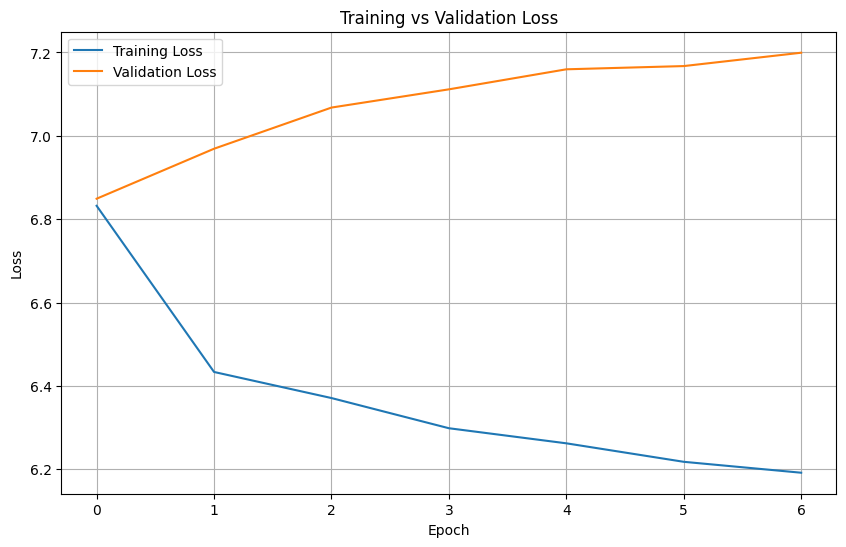

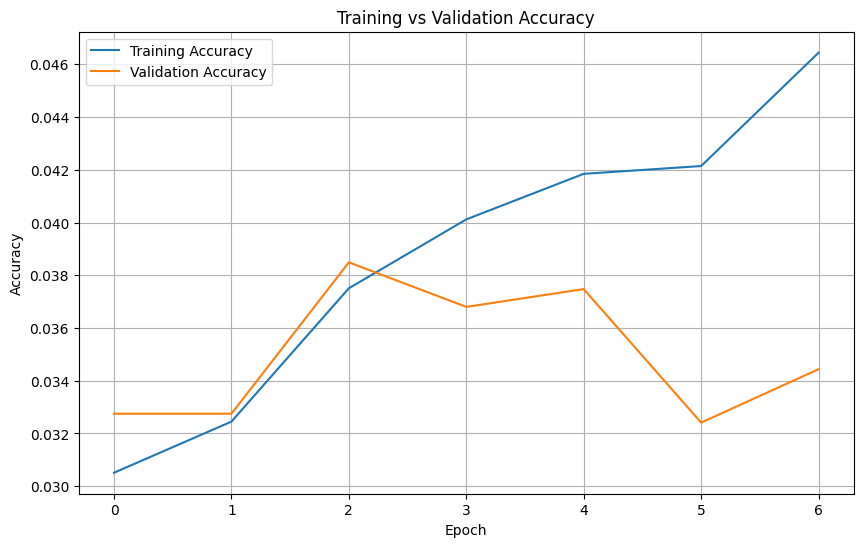

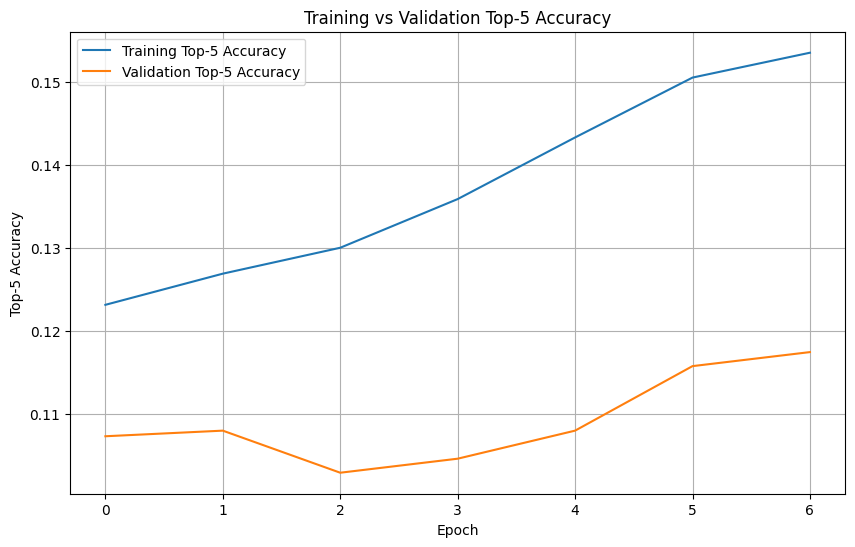

In [20]:
# ============================================================
# CELL 21: PLOT TRAINING HISTORY
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Get training history
# ------------------------------------------------------------

history_dict = history_v2.history


# ============================================================
# 1. LOSS CURVE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_dict["loss"],
    label="Training Loss"
)

plt.plot(
    history_dict["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 2. ACCURACY CURVE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_dict["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_dict["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 3. TOP-5 ACCURACY CURVE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_dict["top_5_accuracy"],
    label="Training Top-5 Accuracy"
)

plt.plot(
    history_dict["val_top_5_accuracy"],
    label="Validation Top-5 Accuracy"
)

plt.title("Training vs Validation Top-5 Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Top-5 Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [21]:
# ============================================================
# CELL 22: TARGET WORD FREQUENCY ANALYSIS
# ============================================================

from collections import Counter


# ------------------------------------------------------------
# Count target-word frequencies
# ------------------------------------------------------------

target_counts = Counter(y_train)


# ------------------------------------------------------------
# Basic statistics
# ------------------------------------------------------------

frequencies = list(target_counts.values())

print("========== TARGET FREQUENCY ANALYSIS ==========")

print(f"Total training samples : {len(y_train):,}")
print(f"Unique target words    : {len(target_counts):,}")

print(f"\nMost frequent target  : {max(frequencies):,}")
print(f"Least frequent target : {min(frequencies):,}")

print(
    f"Average frequency     : "
    f"{np.mean(frequencies):.2f}"
)

print(
    f"Median frequency      : "
    f"{np.median(frequencies):.2f}"
)


# ------------------------------------------------------------
# Frequency buckets
# ------------------------------------------------------------

once = sum(
    1 for count in frequencies
    if count == 1
)

rare = sum(
    1 for count in frequencies
    if count <= 5
)

medium = sum(
    1 for count in frequencies
    if 6 <= count <= 20
)

common = sum(
    1 for count in frequencies
    if count > 20
)


print("\n========== FREQUENCY BUCKETS ==========")

print(f"Appears exactly once : {once:,}")
print(f"Appears 1–5 times    : {rare:,}")
print(f"Appears 6–20 times   : {medium:,}")
print(f"Appears >20 times    : {common:,}")


# ------------------------------------------------------------
# Top 20 most frequent target words
# ------------------------------------------------------------

print("\n========== TOP 20 TARGET WORDS ==========")

for token_id, count in target_counts.most_common(20):

    word = index_to_word.get(
        token_id,
        "<OOV>"
    )

    print(
        f"{word:20s} → {count:,}"
    )

========== TARGET FREQUENCY ANALYSIS ==========
Total training samples : 23,730
Unique target words    : 4,115

Most frequent target  : 769
Least frequent target : 1
Average frequency     : 5.77
Median frequency      : 1.00

========== FREQUENCY BUCKETS ==========
Appears exactly once : 2,542
Appears 1–5 times    : 3,648
Appears 6–20 times   : 305
Appears >20 times    : 162

========== TOP 20 TARGET WORDS ==========
the                  → 769
and                  → 718
to                   → 565
of                   → 500
you                  → 466
i                    → 431
my                   → 424
a                    → 387
it                   → 326
in                   → 316
that                 → 275
ham                  → 250
not                  → 243
is                   → 241
his                  → 226
your                 → 213
with                 → 212
this                 → 205
but                  → 200
for                  → 197


In [22]:
# ============================================================
# CELL 23: VOCABULARY THRESHOLD ANALYSIS
# ============================================================

from collections import Counter


# ------------------------------------------------------------
# Count target-word frequencies
# ------------------------------------------------------------

target_counts = Counter(y_train)


total_targets = len(y_train)


# ------------------------------------------------------------
# Analyze different minimum-frequency thresholds
# ------------------------------------------------------------

thresholds = [2, 3, 5, 10, 20]


print("========== VOCABULARY THRESHOLD ANALYSIS ==========\n")


for threshold in thresholds:

    # Words that satisfy the frequency threshold
    retained_words = {
        token_id
        for token_id, count in target_counts.items()
        if count >= threshold
    }

    # Number of unique words retained
    retained_vocab = len(retained_words)

    # Tokens that would become <UNK>
    unknown_tokens = sum(
        count
        for token_id, count in target_counts.items()
        if count < threshold
    )

    # Percentage of training targets affected
    unknown_percentage = (
        unknown_tokens / total_targets
    ) * 100

    # Percentage of unique vocabulary retained
    vocab_percentage = (
        retained_vocab / len(target_counts)
    ) * 100

    print(f"Minimum frequency : {threshold}")
    print(f"Vocabulary kept   : {retained_vocab:,}")
    print(
        f"Vocabulary kept % : "
        f"{vocab_percentage:.2f}%"
    )
    print(
        f"Tokens → <UNK>    : "
        f"{unknown_tokens:,}"
    )
    print(
        f"Token → <UNK> %   : "
        f"{unknown_percentage:.2f}%"
    )

    print("-" * 55)

========== VOCABULARY THRESHOLD ANALYSIS ==========

Minimum frequency : 2
Vocabulary kept   : 1,573
Vocabulary kept % : 38.23%
Tokens → <UNK>    : 2,542
Token → <UNK> %   : 10.71%
-------------------------------------------------------
Minimum frequency : 3
Vocabulary kept   : 990
Vocabulary kept % : 24.06%
Tokens → <UNK>    : 3,708
Token → <UNK> %   : 15.63%
-------------------------------------------------------
Minimum frequency : 5
Vocabulary kept   : 561
Vocabulary kept % : 13.63%
Tokens → <UNK>    : 5,145
Token → <UNK> %   : 21.68%
-------------------------------------------------------
Minimum frequency : 10
Vocabulary kept   : 317
Vocabulary kept % : 7.70%
Tokens → <UNK>    : 6,726
Token → <UNK> %   : 28.34%
-------------------------------------------------------
Minimum frequency : 20
Vocabulary kept   : 169
Vocabulary kept % : 4.11%
Tokens → <UNK>    : 8,698
Token → <UNK> %   : 36.65%
-------------------------------------------------------


In [23]:
# ============================================================
# CELL 24: BUILD V3 TRAINING-ONLY TOKENIZER
# ============================================================

from tensorflow.keras.preprocessing.text import Tokenizer


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MIN_FREQUENCY = 2


# ------------------------------------------------------------
# First tokenizer
# ------------------------------------------------------------
# We use this temporarily to determine which words meet
# our minimum-frequency requirement.
# ------------------------------------------------------------

frequency_tokenizer = Tokenizer(
    oov_token="<OOV>"
)

frequency_tokenizer.fit_on_texts(
    [train_text]
)


# ------------------------------------------------------------
# Count training vocabulary
# ------------------------------------------------------------

word_counts = frequency_tokenizer.word_counts


# ------------------------------------------------------------
# Keep only words appearing at least MIN_FREQUENCY times
# ------------------------------------------------------------

frequent_words = {
    word
    for word, count in word_counts.items()
    if count >= MIN_FREQUENCY
}


print("========== V3 VOCABULARY FILTER ==========")

print(
    f"Minimum frequency : {MIN_FREQUENCY}"
)

print(
    f"Original vocabulary: "
    f"{len(word_counts):,}"
)

print(
    f"Words retained     : "
    f"{len(frequent_words):,}"
)


# ------------------------------------------------------------
# Create final V3 tokenizer
# ------------------------------------------------------------

tokenizer_v3 = Tokenizer(
    num_words=len(frequent_words) + 2,
    oov_token="<OOV>"
)


# ------------------------------------------------------------
# Fit ONLY on training text
# ------------------------------------------------------------

tokenizer_v3.fit_on_texts(
    [train_text]
)


# ------------------------------------------------------------
# Vocabulary size used by the model
# ------------------------------------------------------------

vocab_size_v3 = len(frequent_words) + 2


print("\n========== V3 TOKENIZER ==========")

print(
    f"V3 vocabulary size : "
    f"{vocab_size_v3:,}"
)

print(
    f"<OOV> token ID     : "
    f"{tokenizer_v3.word_index['<OOV>']}"
)

========== V3 VOCABULARY FILTER ==========
Minimum frequency : 2
Original vocabulary: 4,119
Words retained     : 1,576

========== V3 TOKENIZER ==========
V3 vocabulary size : 1,578
<OOV> token ID     : 1


In [24]:
# ============================================================
# CELL 25: V3 TOKENIZATION + OOV ANALYSIS
# ============================================================

# ------------------------------------------------------------
# Tokenize each split using the V3 tokenizer
# ------------------------------------------------------------

train_sequences_v3 = tokenizer_v3.texts_to_sequences(
    [train_text]
)[0]

val_sequences_v3 = tokenizer_v3.texts_to_sequences(
    [val_text]
)[0]

test_sequences_v3 = tokenizer_v3.texts_to_sequences(
    [test_text]
)[0]


# ------------------------------------------------------------
# OOV token ID
# ------------------------------------------------------------

OOV_ID = tokenizer_v3.word_index["<OOV>"]


# ------------------------------------------------------------
# Function to calculate OOV statistics
# ------------------------------------------------------------

def calculate_oov_stats(tokens, name):

    total_tokens = len(tokens)

    oov_tokens = sum(
        1 for token in tokens
        if token == OOV_ID
    )

    oov_percentage = (
        oov_tokens / total_tokens * 100
        if total_tokens > 0
        else 0
    )

    print(
        f"{name:<12} "
        f"Tokens: {total_tokens:>7,} | "
        f"OOV: {oov_tokens:>6,} | "
        f"OOV %: {oov_percentage:>6.2f}%"
    )


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("========== V3 TOKENIZATION RESULTS ==========")

calculate_oov_stats(
    train_sequences_v3,
    "Training"
)

calculate_oov_stats(
    val_sequences_v3,
    "Validation"
)

calculate_oov_stats(
    test_sequences_v3,
    "Testing"
)


# ------------------------------------------------------------
# Vocabulary information
# ------------------------------------------------------------

print("\n========== V3 VOCABULARY ==========")

print(
    f"Original training vocabulary : "
    f"{len(word_counts):,}"
)

print(
    f"Words retained (freq >= {MIN_FREQUENCY}) : "
    f"{len(frequent_words):,}"
)

print(
    f"Model vocabulary size        : "
    f"{vocab_size_v3:,}"
)

print(
    f"OOV token ID                 : "
    f"{OOV_ID}"
)


# ------------------------------------------------------------
# Sample word → index
# ------------------------------------------------------------

print("\n========== SAMPLE WORD → INDEX ==========")

sample_words = [
    "the",
    "king",
    "hamlet",
    "love",
    "death",
    "shakespeare",
    "selfe"
]

for word in sample_words:

    token_id = tokenizer_v3.word_index.get(
        word,
        None
    )

    # Check whether the word is actually usable
    if token_id is not None and token_id >= vocab_size_v3:
        token_id = OOV_ID

    print(
        f"{word:<12} → {token_id}"
    )

========== V3 TOKENIZATION RESULTS ==========
Training     Tokens:  23,750 | OOV:  2,543 | OOV %:  10.71%
Validation   Tokens:   2,982 | OOV:    612 | OOV %:  20.52%
Testing      Tokens:   2,960 | OOV:    541 | OOV %:  18.28%

========== V3 VOCABULARY ==========
Original training vocabulary : 4,119
Words retained (freq >= 2) : 1,576
Model vocabulary size        : 1,578
OOV token ID                 : 1

========== SAMPLE WORD → INDEX ==========
the          → 2
king         → 30
hamlet       → 50
love         → None
death        → 142
shakespeare  → None
selfe        → 63


In [25]:
# ============================================================
# CELL 26: V3 SEQUENCE DATASET CREATION
# ============================================================

import numpy as np


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

SEQ_LENGTH = 20


# ------------------------------------------------------------
# Function to create input sequences and targets
# ------------------------------------------------------------

def create_sequences(token_sequence, sequence_length):
    """
    Creates next-word prediction samples.

    Example:

    Tokens:
    [1, 2, 3, 4, 5]

    sequence_length = 3

    X:
    [1, 2, 3] -> 4
    [2, 3, 4] -> 5
    """

    X = []
    y = []

    for i in range(
        len(token_sequence) - sequence_length
    ):

        X.append(
            token_sequence[
                i:i + sequence_length
            ]
        )

        y.append(
            token_sequence[
                i + sequence_length
            ]
        )

    return (
        np.array(X, dtype=np.int32),
        np.array(y, dtype=np.int32)
    )


# ------------------------------------------------------------
# Create V3 datasets
# ------------------------------------------------------------

X_train_v3, y_train_v3 = create_sequences(
    train_sequences_v3,
    SEQ_LENGTH
)

X_val_v3, y_val_v3 = create_sequences(
    val_sequences_v3,
    SEQ_LENGTH
)

X_test_v3, y_test_v3 = create_sequences(
    test_sequences_v3,
    SEQ_LENGTH
)


# ============================================================
# DISPLAY SHAPES
# ============================================================

print("========== V3 SEQUENCE DATASET ==========")

print(
    f"Sequence Length : {SEQ_LENGTH}"
)

print()

print(
    f"X_train : {X_train_v3.shape}"
)

print(
    f"y_train : {y_train_v3.shape}"
)

print()

print(
    f"X_val   : {X_val_v3.shape}"
)

print(
    f"y_val   : {y_val_v3.shape}"
)

print()

print(
    f"X_test  : {X_test_v3.shape}"
)

print(
    f"y_test  : {y_test_v3.shape}"
)


# ============================================================
# TARGET INFORMATION
# ============================================================

print("\n========== TARGET FORMAT ==========")

print(
    f"y_train dtype : {y_train_v3.dtype}"
)

print(
    f"y_train shape : {y_train_v3.shape}"
)


# ------------------------------------------------------------
# Show one target
# ------------------------------------------------------------

sample_target_id = y_train_v3[0]

# Reverse lookup
index_to_word_v3 = {
    index: word
    for word, index
    in tokenizer_v3.word_index.items()
}

sample_target_word = index_to_word_v3.get(
    int(sample_target_id),
    "<UNKNOWN>"
)

print(
    f"\nTarget token ID : {sample_target_id}"
)

print(
    f"Target word     : {sample_target_word}"
)

========== V3 SEQUENCE DATASET ==========
Sequence Length : 20

X_train : (23730, 20)
y_train : (23730,)

X_val   : (2962, 20)
y_val   : (2962,)

X_test  : (2940, 20)
y_test  : (2940,)

========== TARGET FORMAT ==========
y_train dtype : int32
y_train shape : (23730,)

Target token ID : 63
Target word     : selfe


In [26]:
# ============================================================
# CELL 27: V3 SEQUENCE SANITY CHECK
# ============================================================

print("========== V3 SEQUENCE SANITY CHECK ==========")


# ------------------------------------------------------------
# Reverse vocabulary
# ------------------------------------------------------------

index_to_word_v3 = {
    index: word
    for word, index
    in tokenizer_v3.word_index.items()
}


# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def decode_sequence_v3(sequence):

    words = []

    for token_id in sequence:

        token_id = int(token_id)

        if token_id == 0:
            word = "<PAD>"

        elif token_id == OOV_ID:
            word = "<OOV>"

        else:
            word = index_to_word_v3.get(
                token_id,
                "<UNKNOWN>"
            )

        words.append(word)

    return " ".join(words)


# ------------------------------------------------------------
# Check first 3 training sequences
# ------------------------------------------------------------

for i in range(3):

    print(f"\nSequence {i + 1}")
    print("-" * 70)

    print("Input:")
    print(
        decode_sequence_v3(
            X_train_v3[i]
        )
    )

    print("\nTarget:")

    target_id = int(y_train_v3[i])

    if target_id == OOV_ID:
        target_word = "<OOV>"
    else:
        target_word = index_to_word_v3.get(
            target_id,
            "<UNKNOWN>"
        )

    print(target_word)

    print("\nInput Length:")
    print(len(X_train_v3[i]))

    print("=" * 70)


# ============================================================
# OOV SEQUENCE CHECK
# ============================================================

print("\n========== OOV SEQUENCE CHECK ==========")


# Find a training sequence containing OOV
oov_indices = np.where(
    np.any(X_train_v3 == OOV_ID, axis=1)
)[0]


if len(oov_indices) > 0:

    idx = oov_indices[0]

    print(
        f"Found OOV-containing sequence at index: {idx}"
    )

    print("\nInput:")
    print(
        decode_sequence_v3(
            X_train_v3[idx]
        )
    )

    target_id = int(y_train_v3[idx])

    if target_id == OOV_ID:
        target_word = "<OOV>"
    else:
        target_word = index_to_word_v3.get(
            target_id,
            "<UNKNOWN>"
        )

    print("\nTarget:")
    print(target_word)

else:

    print(
        "No OOV-containing training sequence found."
    )


# ============================================================
# TOKEN RANGE CHECK
# ============================================================

print("\n========== TOKEN RANGE CHECK ==========")

print(
    f"Minimum X_train token ID : "
    f"{X_train_v3.min()}"
)

print(
    f"Maximum X_train token ID : "
    f"{X_train_v3.max()}"
)

print(
    f"Minimum y_train token ID : "
    f"{y_train_v3.min()}"
)

print(
    f"Maximum y_train token ID : "
    f"{y_train_v3.max()}"
)

print(
    f"Valid token range        : "
    f"0 → {vocab_size_v3 - 1}"
)


# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert X_train_v3.shape[1] == SEQ_LENGTH

assert X_train_v3.min() >= 0
assert X_train_v3.max() < vocab_size_v3

assert y_train_v3.min() >= 0
assert y_train_v3.max() < vocab_size_v3

assert X_val_v3.min() >= 0
assert X_val_v3.max() < vocab_size_v3

assert y_val_v3.min() >= 0
assert y_val_v3.max() < vocab_size_v3

assert X_test_v3.min() >= 0
assert X_test_v3.max() < vocab_size_v3

assert y_test_v3.min() >= 0
assert y_test_v3.max() < vocab_size_v3


print("\n✅ ALL V3 SEQUENCE CHECKS PASSED")

========== V3 SEQUENCE SANITY CHECK ==========

Sequence 1
----------------------------------------------------------------------
Input:
actus <OOV> <OOV> <OOV> enter barnardo and francisco two <OOV> barnardo who's there fran nay answer me stand vnfold your

Target:
selfe

Input Length:
20

Sequence 2
----------------------------------------------------------------------
Input:
<OOV> <OOV> <OOV> enter barnardo and francisco two <OOV> barnardo who's there fran nay answer me stand vnfold your selfe

Target:
bar

Input Length:
20

Sequence 3
----------------------------------------------------------------------
Input:
<OOV> <OOV> enter barnardo and francisco two <OOV> barnardo who's there fran nay answer me stand vnfold your selfe bar

Target:
long

Input Length:
20

========== OOV SEQUENCE CHECK ==========
Found OOV-containing sequence at index: 0

Input:
actus <OOV> <OOV> <OOV> enter barnardo and francisco two <OOV> barnardo who's there fran nay answer me stand vnfold your

Target:
self

In [28]:
# ============================================================
# CELL 28: BUILD V3 LSTM MODEL
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

tf.keras.utils.set_random_seed(42)


# ------------------------------------------------------------
# V3 configuration
# ------------------------------------------------------------

EMBEDDING_DIM = 64
LSTM_UNITS = 64
DROPOUT_RATE = 0.30


print("========== V3 MODEL CONFIGURATION ==========")

print(f"Vocabulary size : {vocab_size_v3:,}")
print(f"Embedding dim   : {EMBEDDING_DIM}")
print(f"LSTM units      : {LSTM_UNITS}")
print(f"Dropout         : {DROPOUT_RATE}")
print(f"Sequence length : {SEQ_LENGTH}")


# ------------------------------------------------------------
# Build V3 model
# ------------------------------------------------------------

model_v3 = keras.Sequential([

    # Explicit input layer
    layers.Input(
        shape=(SEQ_LENGTH,),
        dtype="int32",
        name="input"
    ),

    # Word embeddings
    layers.Embedding(
        input_dim=vocab_size_v3,
        output_dim=EMBEDDING_DIM,
        name="embedding"
    ),

    # LSTM
    layers.LSTM(
        LSTM_UNITS,
        name="lstm"
    ),

    # Regularization
    layers.Dropout(
        DROPOUT_RATE,
        name="dropout"
    ),

    # Next-word prediction
    layers.Dense(
        vocab_size_v3,
        activation="softmax",
        name="output"
    )
])


# ------------------------------------------------------------
# Compile model
# ------------------------------------------------------------

model_v3.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy",

        keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)


# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

print("\n========== V3 MODEL SUMMARY ==========")

model_v3.summary()


# ------------------------------------------------------------
# Parameter information
# ------------------------------------------------------------

print("\n========== V3 PARAMETER COUNT ==========")

print(
    f"Total parameters : "
    f"{model_v3.count_params():,}"
)

========== V3 MODEL CONFIGURATION ==========
Vocabulary size : 1,578
Embedding dim   : 64
LSTM units      : 64
Dropout         : 0.3
Sequence length : 20

========== V3 MODEL SUMMARY ==========


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 64)         │       100,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1578)           │       102,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,586 (924.16 KB)

 Trainable params: 236,586 (924.16 KB)

 Non-trainable params: 0 (0.00 B)


========== V3 PARAMETER COUNT ==========
Total parameters : 236,586


In [29]:
# ============================================================
# CELL 29: V3 TRAINING CALLBACKS
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)


# ------------------------------------------------------------
# Early Stopping
# ------------------------------------------------------------
# Stop training when validation loss stops improving.
# Restore the weights from the best epoch.

early_stopping_v3 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)


# ------------------------------------------------------------
# Reduce Learning Rate
# ------------------------------------------------------------
# If validation loss stops improving, reduce the learning rate.

reduce_lr_v3 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)


# ------------------------------------------------------------
# Model Checkpoint
# ------------------------------------------------------------
# Save only the model with the best validation loss.

checkpoint_v3 = ModelCheckpoint(
    "best_lstm_v3.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


# ------------------------------------------------------------
# Combine callbacks
# ------------------------------------------------------------

callbacks_v3 = [
    early_stopping_v3,
    reduce_lr_v3,
    checkpoint_v3
]


# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

print("========== V3 TRAINING CALLBACKS ==========")

print("1. EarlyStopping")
print("   Monitor  : val_loss")
print("   Patience : 4")

print("\n2. ReduceLROnPlateau")
print("   Monitor  : val_loss")
print("   Factor   : 0.5")
print("   Patience : 2")
print("   Min LR   : 1e-5")

print("\n3. ModelCheckpoint")
print("   Monitor  : val_loss")
print("   File     : best_lstm_v3.keras")

print("\n✅ V3 callbacks configured successfully!")

========== V3 TRAINING CALLBACKS ==========
1. EarlyStopping
   Monitor  : val_loss
   Patience : 4

2. ReduceLROnPlateau
   Monitor  : val_loss
   Factor   : 0.5
   Patience : 2
   Min LR   : 1e-5

3. ModelCheckpoint
   Monitor  : val_loss
   File     : best_lstm_v3.keras

✅ V3 callbacks configured successfully!


In [30]:
# ============================================================
# CELL 30: TRAIN V3 LSTM MODEL
# ============================================================

print("========== V3 TRAINING STARTED ==========")

history_v3 = model_v3.fit(
    X_train_v3,
    y_train_v3,

    validation_data=(
        X_val_v3,
        y_val_v3
    ),

    epochs=30,

    batch_size=64,

    callbacks=callbacks_v3,

    verbose=1
)


print("\n========================================")
print("V3 TRAINING COMPLETED")
print("========================================")

========== V3 TRAINING STARTED ==========
Epoch 1/30
365/371 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1026 - loss: 6.2128 - top_5_accuracy: 0.1967
Epoch 1: val_loss improved from None to 5.17152, saving model to best_lstm_v3.keras

Epoch 1: finished saving model to best_lstm_v3.keras
371/371 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.1058 - loss: 5.8741 - top_5_accuracy: 0.2071 - val_accuracy: 0.2053 - val_loss: 5.1715 - val_top_5_accuracy: 0.2978 - learning_rate: 0.0010
Epoch 2/30
368/371 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1091 - loss: 5.6077 - top_5_accuracy: 0.2166
Epoch 2: val_loss improved from 5.17152 to 5.17016, saving model to best_lstm_v3.keras

Epoch 2: finished saving model to best_lstm_v3.keras
371/371 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1070 - loss: 5.6247 - top_5_accuracy: 0.2137 - val_accuracy: 0.2053 - val_loss: 5.1702 - val_top_5_accuracy: 0.2978 - learning_rate: 0.0010
Epoch 3/30
365/371 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1

In [31]:
# ============================================================
# CELL 31: V3 MODEL EVALUATION
# ============================================================

print("========== V3 MODEL EVALUATION ==========")


# ------------------------------------------------------------
# Evaluate on training data
# ------------------------------------------------------------

train_results_v3 = model_v3.evaluate(
    X_train_v3,
    y_train_v3,
    verbose=0
)


# ------------------------------------------------------------
# Evaluate on validation data
# ------------------------------------------------------------

val_results_v3 = model_v3.evaluate(
    X_val_v3,
    y_val_v3,
    verbose=0
)


# ------------------------------------------------------------
# Evaluate on test data
# ------------------------------------------------------------

test_results_v3 = model_v3.evaluate(
    X_test_v3,
    y_test_v3,
    verbose=0
)


# ------------------------------------------------------------
# Extract metrics
# ------------------------------------------------------------

train_loss_v3 = train_results_v3[0]
train_acc_v3 = train_results_v3[1]
train_top5_v3 = train_results_v3[2]

val_loss_v3 = val_results_v3[0]
val_acc_v3 = val_results_v3[1]
val_top5_v3 = val_results_v3[2]

test_loss_v3 = test_results_v3[0]
test_acc_v3 = test_results_v3[1]
test_top5_v3 = test_results_v3[2]


# ------------------------------------------------------------
# Perplexity
# ------------------------------------------------------------

import numpy as np

test_perplexity_v3 = np.exp(test_loss_v3)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nTRAINING RESULTS")
print("-" * 50)

print(f"Loss          : {train_loss_v3:.4f}")
print(f"Accuracy      : {train_acc_v3:.4f}")
print(f"Top-5 Accuracy: {train_top5_v3:.4f}")


print("\nVALIDATION RESULTS")
print("-" * 50)

print(f"Loss          : {val_loss_v3:.4f}")
print(f"Accuracy      : {val_acc_v3:.4f}")
print(f"Top-5 Accuracy: {val_top5_v3:.4f}")


print("\nTEST RESULTS")
print("-" * 50)

print(f"Loss          : {test_loss_v3:.4f}")
print(f"Accuracy      : {test_acc_v3:.4f}")
print(f"Top-5 Accuracy: {test_top5_v3:.4f}")
print(f"Perplexity    : {test_perplexity_v3:.2f}")


# ------------------------------------------------------------
# Generalization gap
# ------------------------------------------------------------

accuracy_gap_v3 = train_acc_v3 - val_acc_v3
loss_gap_v3 = val_loss_v3 - train_loss_v3


print("\nGENERALIZATION GAP")
print("-" * 50)

print(
    f"Accuracy gap : {accuracy_gap_v3:.4f}"
)

print(
    f"Loss gap     : {loss_gap_v3:.4f}"
)


print("\n========================================")
print("V3 EVALUATION COMPLETED")
print("========================================")

========== V3 MODEL EVALUATION ==========

TRAINING RESULTS
--------------------------------------------------
Loss          : 4.6822
Accuracy      : 0.1588
Top-5 Accuracy: 0.3343

VALIDATION RESULTS
--------------------------------------------------
Loss          : 4.8895
Accuracy      : 0.1880
Top-5 Accuracy: 0.3474

TEST RESULTS
--------------------------------------------------
Loss          : 4.7985
Accuracy      : 0.1850
Top-5 Accuracy: 0.3602
Perplexity    : 121.33

GENERALIZATION GAP
--------------------------------------------------
Accuracy gap : -0.0292
Loss gap     : 0.2073

V3 EVALUATION COMPLETED


In [32]:
# ============================================================
# CELL 32: V3 NEXT-WORD PREDICTION ANALYSIS
# ============================================================

import numpy as np


print("========== V3 PREDICTION ANALYSIS ==========")


# ------------------------------------------------------------
# Helper: token ID → word
# ------------------------------------------------------------

def token_to_word_v3(token_id):

    token_id = int(token_id)

    if token_id == 0:
        return "<PAD>"

    if token_id == OOV_ID:
        return "<OOV>"

    return index_to_word_v3.get(
        token_id,
        "<UNKNOWN>"
    )


# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

sample_count = 10

sample_X = X_test_v3[:sample_count]
sample_y = y_test_v3[:sample_count]

predictions_v3 = model_v3.predict(
    sample_X,
    verbose=0
)


# ------------------------------------------------------------
# Display predictions
# ------------------------------------------------------------

for i in range(sample_count):

    print("\n" + "=" * 80)

    print(f"Sample {i + 1}")

    print("-" * 80)

    # Input
    input_words = [
        token_to_word_v3(token_id)
        for token_id in sample_X[i]
    ]

    print("Input:")
    print(" ".join(input_words))


    # Actual target
    actual_word = token_to_word_v3(
        sample_y[i]
    )

    print("\nActual:")
    print(actual_word)


    # Top-5 predictions
    top5_ids = np.argsort(
        predictions_v3[i]
    )[-5:][::-1]


    print("\nTop-5 Predictions:")

    for rank, token_id in enumerate(
        top5_ids,
        start=1
    ):

        word = token_to_word_v3(token_id)

        probability = predictions_v3[
            i,
            token_id
        ]

        print(
            f"{rank}. "
            f"{word:<15} "
            f"{probability:.4f}"
        )


print("\n========================================")
print("V3 PREDICTION ANALYSIS COMPLETED")
print("========================================")

========== V3 PREDICTION ANALYSIS ==========

Sample 1
--------------------------------------------------------------------------------
Input:
<OOV> so much for this sir now let me see the other you doe remember all the circumstance hor remember

Actual:
it

Top-5 Predictions:
1. you             0.0933
2. me              0.0500
3. what            0.0434
4. it              0.0408
5. my              0.0406

Sample 2
--------------------------------------------------------------------------------
Input:
so much for this sir now let me see the other you doe remember all the circumstance hor remember it

Actual:
my

Top-5 Predictions:
1. is              0.0775
2. <OOV>           0.0324
3. are             0.0221
4. shall           0.0192
5. i               0.0178

Sample 3
--------------------------------------------------------------------------------
Input:
much for this sir now let me see the other you doe remember all the circumstance hor remember it my

Actual:
lord

Top-5 Predictions:


In [33]:
# ============================================================
# CELL 33: V4 LSTM MODEL
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

tf.keras.utils.set_random_seed(42)


# ------------------------------------------------------------
# V4 configuration
# ------------------------------------------------------------

EMBEDDING_DIM_V4 = 128
LSTM_UNITS_V4 = 128
DROPOUT_RATE_V4 = 0.30


print("========== V4 MODEL CONFIGURATION ==========")

print(f"Vocabulary size : {vocab_size_v3:,}")
print(f"Embedding dim   : {EMBEDDING_DIM_V4}")
print(f"LSTM units      : {LSTM_UNITS_V4}")
print(f"Dropout         : {DROPOUT_RATE_V4}")
print(f"Sequence length : {SEQ_LENGTH}")


# ------------------------------------------------------------
# Build V4 model
# ------------------------------------------------------------

model_v4 = keras.Sequential([

    layers.Input(
        shape=(SEQ_LENGTH,),
        dtype="int32",
        name="input"
    ),

    layers.Embedding(
        input_dim=vocab_size_v3,
        output_dim=EMBEDDING_DIM_V4,
        name="embedding"
    ),

    layers.LSTM(
        LSTM_UNITS_V4,
        name="lstm"
    ),

    layers.Dropout(
        DROPOUT_RATE_V4,
        name="dropout"
    ),

    layers.Dense(
        vocab_size_v3,
        activation="softmax",
        name="output"
    )
])


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

model_v4.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy",

        keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n========== V4 MODEL SUMMARY ==========")

model_v4.summary()


# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------

print("\n========== V4 PARAMETER COUNT ==========")

print(
    f"Total parameters : "
    f"{model_v4.count_params():,}"
)

========== V4 MODEL CONFIGURATION ==========
Vocabulary size : 1,578
Embedding dim   : 128
LSTM units      : 128
Dropout         : 0.3
Sequence length : 20

========== V4 MODEL SUMMARY ==========


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 128)        │       201,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1578)           │       203,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 537,130 (2.05 MB)

 Trainable params: 537,130 (2.05 MB)

 Non-trainable params: 0 (0.00 B)


========== V4 PARAMETER COUNT ==========
Total parameters : 537,130


In [34]:
# ============================================================
# CELL 34: V4 TRAINING CALLBACKS
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)


# ------------------------------------------------------------
# Early Stopping
# ------------------------------------------------------------

early_stopping_v4 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)


# ------------------------------------------------------------
# Learning Rate Reduction
# ------------------------------------------------------------

reduce_lr_v4 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)


# ------------------------------------------------------------
# Model Checkpoint
# ------------------------------------------------------------

checkpoint_v4 = ModelCheckpoint(
    "best_lstm_v4.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


# ------------------------------------------------------------
# Callback list
# ------------------------------------------------------------

callbacks_v4 = [
    early_stopping_v4,
    reduce_lr_v4,
    checkpoint_v4
]


print("========== V4 TRAINING CALLBACKS ==========")

print("1. EarlyStopping")
print("   Monitor  : val_loss")
print("   Patience : 4")

print("\n2. ReduceLROnPlateau")
print("   Monitor  : val_loss")
print("   Factor   : 0.5")
print("   Patience : 2")
print("   Min LR   : 1e-5")

print("\n3. ModelCheckpoint")
print("   Monitor  : val_loss")
print("   File     : best_lstm_v4.keras")

print("\n✅ V4 callbacks configured successfully!")

========== V4 TRAINING CALLBACKS ==========
1. EarlyStopping
   Monitor  : val_loss
   Patience : 4

2. ReduceLROnPlateau
   Monitor  : val_loss
   Factor   : 0.5
   Patience : 2
   Min LR   : 1e-5

3. ModelCheckpoint
   Monitor  : val_loss
   File     : best_lstm_v4.keras

✅ V4 callbacks configured successfully!


In [35]:
# ============================================================
# CELL 35: V4 MODEL TRAINING
# ============================================================

print("========== V4 TRAINING STARTED ==========")

history_v4 = model_v4.fit(
    X_train_v3,
    y_train_v3,

    validation_data=(
        X_val_v3,
        y_val_v3
    ),

    epochs=30,
    batch_size=64,

    callbacks=callbacks_v4,

    verbose=1
)


print("\n========================================")
print("V4 TRAINING COMPLETED")
print("========================================")

========== V4 TRAINING STARTED ==========
Epoch 1/30
364/371 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1036 - loss: 6.0957 - top_5_accuracy: 0.1967
Epoch 1: val_loss improved from None to 5.16162, saving model to best_lstm_v4.keras

Epoch 1: finished saving model to best_lstm_v4.keras
371/371 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.1060 - loss: 5.8189 - top_5_accuracy: 0.2079 - val_accuracy: 0.2053 - val_loss: 5.1616 - val_top_5_accuracy: 0.2978 - learning_rate: 0.0010
Epoch 2/30
370/371 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1093 - loss: 5.5586 - top_5_accuracy: 0.2230
Epoch 2: val_loss improved from 5.16162 to 5.05332, saving model to best_lstm_v4.keras

Epoch 2: finished saving model to best_lstm_v4.keras
371/371 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1077 - loss: 5.5528 - top_5_accuracy: 0.2250 - val_accuracy: 0.2049 - val_loss: 5.0533 - val_top_5_accuracy: 0.3065 - learning_rate: 0.0010
Epoch 3/30
363/371 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1

In [36]:
# ============================================================
# CELL 36: V4 MODEL EVALUATION
# ============================================================

print("========== V4 MODEL EVALUATION ==========")


# ------------------------------------------------------------
# Evaluate training set
# ------------------------------------------------------------

train_results_v4 = model_v4.evaluate(
    X_train_v3,
    y_train_v3,
    verbose=0
)


# ------------------------------------------------------------
# Evaluate validation set
# ------------------------------------------------------------

val_results_v4 = model_v4.evaluate(
    X_val_v3,
    y_val_v3,
    verbose=0
)


# ------------------------------------------------------------
# Evaluate test set
# ------------------------------------------------------------

test_results_v4 = model_v4.evaluate(
    X_test_v3,
    y_test_v3,
    verbose=0
)


# ------------------------------------------------------------
# Extract metrics
# ------------------------------------------------------------

train_loss_v4 = train_results_v4[0]
train_acc_v4 = train_results_v4[1]
train_top5_v4 = train_results_v4[2]

val_loss_v4 = val_results_v4[0]
val_acc_v4 = val_results_v4[1]
val_top5_v4 = val_results_v4[2]

test_loss_v4 = test_results_v4[0]
test_acc_v4 = test_results_v4[1]
test_top5_v4 = test_results_v4[2]


# ------------------------------------------------------------
# Perplexity
# ------------------------------------------------------------

test_perplexity_v4 = np.exp(test_loss_v4)


# ------------------------------------------------------------
# Generalization gaps
# ------------------------------------------------------------

accuracy_gap_v4 = train_acc_v4 - val_acc_v4
loss_gap_v4 = val_loss_v4 - train_loss_v4


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\nTRAINING RESULTS")
print("-" * 50)

print(f"Loss           : {train_loss_v4:.4f}")
print(f"Accuracy       : {train_acc_v4:.4f}")
print(f"Top-5 Accuracy : {train_top5_v4:.4f}")


print("\nVALIDATION RESULTS")
print("-" * 50)

print(f"Loss           : {val_loss_v4:.4f}")
print(f"Accuracy       : {val_acc_v4:.4f}")
print(f"Top-5 Accuracy : {val_top5_v4:.4f}")


print("\nTEST RESULTS")
print("-" * 50)

print(f"Loss           : {test_loss_v4:.4f}")
print(f"Accuracy       : {test_acc_v4:.4f}")
print(f"Top-5 Accuracy : {test_top5_v4:.4f}")
print(f"Perplexity     : {test_perplexity_v4:.2f}")


print("\nGENERALIZATION GAP")
print("-" * 50)

print(f"Accuracy gap   : {accuracy_gap_v4:.4f}")
print(f"Loss gap       : {loss_gap_v4:.4f}")


print("\n========================================")
print("V4 EVALUATION COMPLETED")
print("========================================")

========== V4 MODEL EVALUATION ==========

TRAINING RESULTS
--------------------------------------------------
Loss           : 4.5749
Accuracy       : 0.1611
Top-5 Accuracy : 0.3465

VALIDATION RESULTS
--------------------------------------------------
Loss           : 4.8676
Accuracy       : 0.1918
Top-5 Accuracy : 0.3531

TEST RESULTS
--------------------------------------------------
Loss           : 4.7821
Accuracy       : 0.1939
Top-5 Accuracy : 0.3558
Perplexity     : 119.36

GENERALIZATION GAP
--------------------------------------------------
Accuracy gap   : -0.0306
Loss gap       : 0.2927

V4 EVALUATION COMPLETED


In [37]:
# ============================================================
# CELL 37: V3 vs V4 COMPARISON
# ============================================================

print("========== V3 vs V4 COMPARISON ==========")

print()

print(f"{'Metric':<25} {'V3':>12} {'V4':>12} {'Change':>12}")
print("-" * 65)

print(
    f"{'Parameters':<25} "
    f"{236586:>12,} "
    f"{537130:>12,} "
    f"{537130 - 236586:>+12,}"
)

print(
    f"{'Train Accuracy':<25} "
    f"{0.1588:>12.4f} "
    f"{train_acc_v4:>12.4f} "
    f"{train_acc_v4 - 0.1588:>+12.4f}"
)

print(
    f"{'Validation Accuracy':<25} "
    f"{0.1880:>12.4f} "
    f"{val_acc_v4:>12.4f} "
    f"{val_acc_v4 - 0.1880:>+12.4f}"
)

print(
    f"{'Test Accuracy':<25} "
    f"{0.1850:>12.4f} "
    f"{test_acc_v4:>12.4f} "
    f"{test_acc_v4 - 0.1850:>+12.4f}"
)

print(
    f"{'Test Top-5 Accuracy':<25} "
    f"{0.3602:>12.4f} "
    f"{test_top5_v4:>12.4f} "
    f"{test_top5_v4 - 0.3602:>+12.4f}"
)

print(
    f"{'Test Loss':<25} "
    f"{4.7985:>12.4f} "
    f"{test_loss_v4:>12.4f} "
    f"{test_loss_v4 - 4.7985:>+12.4f}"
)

print(
    f"{'Perplexity':<25} "
    f"{121.33:>12.2f} "
    f"{test_perplexity_v4:>12.2f} "
    f"{test_perplexity_v4 - 121.33:>+12.2f}"
)

print()
print("=" * 65)

print("\nKEY OBSERVATION:")
print(
    "V4 uses more than twice the parameters of V3, "
    "but the improvement in test accuracy is small."
)

print(
    f"\nTest Accuracy: "
    f"{0.1850:.2%} → {test_acc_v4:.2%}"
)

print(
    f"Test Top-5: "
    f"{0.3602:.2%} → {test_top5_v4:.2%}"
)

print("\n========================================")
print("V3 vs V4 COMPARISON COMPLETED")
print("========================================")

========== V3 vs V4 COMPARISON ==========

Metric                              V3           V4       Change
-----------------------------------------------------------------
Parameters                     236,586      537,130     +300,544
Train Accuracy                  0.1588       0.1611      +0.0023
Validation Accuracy             0.1880       0.1918      +0.0038
Test Accuracy                   0.1850       0.1939      +0.0089
Test Top-5 Accuracy             0.3602       0.3558      -0.0044
Test Loss                       4.7985       4.7821      -0.0164
Perplexity                      121.33       119.36        -1.97


KEY OBSERVATION:
V4 uses more than twice the parameters of V3, but the improvement in test accuracy is small.

Test Accuracy: 18.50% → 19.39%
Test Top-5: 36.02% → 35.58%

V3 vs V4 COMPARISON COMPLETED


In [42]:
# ============================================================
# V5 — CHECK V3 TOKENIZER
# ============================================================

print("=" * 60)
print("V3 TOKENIZER CHECK")
print("=" * 60)

print("Tokenizer type :", type(tokenizer_v3).__name__)
print("Vocabulary size:", len(tokenizer_v3.word_index) + 1)

print("\nSample word → index:")

for word in ["the", "king", "hamlet", "love", "death", "selfe"]:
    print(f"{word:12s} → {tokenizer_v3.word_index.get(word)}")

V3 TOKENIZER CHECK
Tokenizer type : Tokenizer
Vocabulary size: 4121

Sample word → index:
the          → 2
king         → 30
hamlet       → 50
love         → None
death        → 142
selfe        → 63


In [43]:
# ============================================================
# CHECK FREQUENCY TOKENIZER
# ============================================================

print("=" * 60)
print("FREQUENCY TOKENIZER CHECK")
print("=" * 60)

print("Tokenizer type :", type(frequency_tokenizer).__name__)
print("Vocabulary size:", len(frequency_tokenizer.word_index) + 1)

print("\nSample word → index:")

for word in ["the", "king", "hamlet", "love", "death", "shakespeare", "selfe"]:
    print(f"{word:12s} → {frequency_tokenizer.word_index.get(word)}")

print("\nOOV token:")
print("OOV token:", frequency_tokenizer.oov_token)
print("OOV ID   :", frequency_tokenizer.word_index.get(frequency_tokenizer.oov_token))

FREQUENCY TOKENIZER CHECK
Tokenizer type : Tokenizer
Vocabulary size: 4121

Sample word → index:
the          → 2
king         → 30
hamlet       → 50
love         → None
death        → 142
shakespeare  → None
selfe        → 63

OOV token:
OOV token: <OOV>
OOV ID   : 1


In [44]:
# ============================================================
# V5 — RECONSTRUCT FILTERED TOKENIZER
# ============================================================

from tensorflow.keras.preprocessing.text import Tokenizer

MIN_FREQUENCY = 2

# ------------------------------------------------------------
# Get word frequencies from the original tokenizer
# ------------------------------------------------------------

word_counts = frequency_tokenizer.word_counts

# Keep only words appearing at least MIN_FREQUENCY times
filtered_words = {
    word: count
    for word, count in word_counts.items()
    if count >= MIN_FREQUENCY
}

print("=" * 60)
print("V5 TOKENIZER RECONSTRUCTION")
print("=" * 60)

print(f"Minimum frequency       : {MIN_FREQUENCY}")
print(f"Original vocabulary     : {len(word_counts):,}")
print(f"Words retained          : {len(filtered_words):,}")


# ------------------------------------------------------------
# Create filtered tokenizer
# ------------------------------------------------------------

tokenizer_v5 = Tokenizer(
    num_words=len(filtered_words) + 2,
    oov_token="<OOV>"
)

# Fit on the original training text
tokenizer_v5.fit_on_texts(train_text)


# ------------------------------------------------------------
# Verify vocabulary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("V5 TOKENIZER")
print("=" * 60)

print(
    f"V5 vocabulary size : "
    f"{len(tokenizer_v5.word_index) + 1:,}"
)

print(
    f"OOV token ID       : "
    f"{tokenizer_v5.word_index.get('<OOV>')}"
)


# ------------------------------------------------------------
# Sample word → index
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SAMPLE WORD → INDEX")
print("=" * 60)

for word in [
    "the",
    "king",
    "hamlet",
    "love",
    "death",
    "shakespeare",
    "selfe"
]:
    print(
        f"{word:12s} → "
        f"{tokenizer_v5.word_index.get(word)}"
    )

V5 TOKENIZER RECONSTRUCTION
Minimum frequency       : 2
Original vocabulary     : 4,119
Words retained          : 1,576

V5 TOKENIZER
V5 vocabulary size : 30
OOV token ID       : 1

SAMPLE WORD → INDEX
the          → None
king         → None
hamlet       → None
love         → None
death        → None
shakespeare  → None
selfe        → None


In [45]:
# ============================================================
# V5 — REBUILD FILTERED TOKENIZER CORRECTLY
# ============================================================

from tensorflow.keras.preprocessing.text import Tokenizer

MIN_FREQUENCY = 2

# ------------------------------------------------------------
# 1. Get word frequencies from original tokenizer
# ------------------------------------------------------------

word_counts = frequency_tokenizer.word_counts

# Keep words appearing at least 2 times
filtered_words = {
    word: count
    for word, count in word_counts.items()
    if count >= MIN_FREQUENCY
}

print("=" * 60)
print("V5 TOKENIZER RECONSTRUCTION")
print("=" * 60)

print(f"Minimum frequency   : {MIN_FREQUENCY}")
print(f"Original vocabulary : {len(word_counts):,}")
print(f"Words retained      : {len(filtered_words):,}")


# ------------------------------------------------------------
# 2. Sort words in the SAME order as the original tokenizer
# ------------------------------------------------------------
#
# Keras originally assigns indices according to word frequency.
# We preserve that ordering instead of fitting a new tokenizer.
# ------------------------------------------------------------

sorted_words = sorted(
    filtered_words.keys(),
    key=lambda word: (
        -filtered_words[word],
        word
    )
)


# ------------------------------------------------------------
# 3. Manually construct word → index mapping
# ------------------------------------------------------------

word_index_v5 = {
    "<OOV>": 1
}

for idx, word in enumerate(sorted_words, start=2):
    word_index_v5[word] = idx


# ------------------------------------------------------------
# 4. Create reverse mapping
# ------------------------------------------------------------

index_word_v5 = {
    index: word
    for word, index in word_index_v5.items()
}


# ------------------------------------------------------------
# 5. Verify vocabulary
# ------------------------------------------------------------

VOCAB_SIZE_V5 = len(word_index_v5) + 1

print("\n" + "=" * 60)
print("V5 VOCABULARY")
print("=" * 60)

print(f"Vocabulary size : {VOCAB_SIZE_V5:,}")
print(f"OOV token ID    : {word_index_v5['<OOV>']}")


# ------------------------------------------------------------
# 6. Sample word → index
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SAMPLE WORD → INDEX")
print("=" * 60)

for word in [
    "the",
    "king",
    "hamlet",
    "love",
    "death",
    "shakespeare",
    "selfe"
]:
    print(
        f"{word:12s} → "
        f"{word_index_v5.get(word)}"
    )

V5 TOKENIZER RECONSTRUCTION
Minimum frequency   : 2
Original vocabulary : 4,119
Words retained      : 1,576

V5 VOCABULARY
Vocabulary size : 1,578
OOV token ID    : 1

SAMPLE WORD → INDEX
the          → 2
king         → 30
hamlet       → 50
love         → None
death        → 137
shakespeare  → None
selfe        → 63


In [46]:
# ============================================================
# V5 TOKENIZER — MAPPING VERIFICATION
# ============================================================

reference_words = {
    "the": 2,
    "king": 30,
    "hamlet": 50,
    "selfe": 63,
    "death": 142
}

print("=" * 60)
print("V5 TOKENIZER MAPPING VERIFICATION")
print("=" * 60)

all_match = True

for word, expected_id in reference_words.items():

    actual_id = word_index_v5.get(word)

    status = "✓ MATCH" if actual_id == expected_id else "✗ DIFFERENT"

    print(
        f"{word:12s} | "
        f"Expected: {expected_id:4d} | "
        f"Actual: {str(actual_id):>4s} | "
        f"{status}"
    )

    if actual_id != expected_id:
        all_match = False

print("\n" + "=" * 60)

if all_match:
    print("✅ All reference mappings match V3.")
else:
    print("⚠️ Some mappings differ from V3.")
    print("We will verify the original V3 ordering before continuing.")

V5 TOKENIZER MAPPING VERIFICATION
the          | Expected:    2 | Actual:    2 | ✓ MATCH
king         | Expected:   30 | Actual:   30 | ✓ MATCH
hamlet       | Expected:   50 | Actual:   50 | ✓ MATCH
selfe        | Expected:   63 | Actual:   63 | ✓ MATCH
death        | Expected:  142 | Actual:  137 | ✗ DIFFERENT

⚠️ Some mappings differ from V3.
We will verify the original V3 ordering before continuing.


In [47]:
# ============================================================
# CELL 29 — VERIFY ORIGINAL V3 TOKENIZER MAPPING
# ============================================================

print("=" * 60)
print("V3 TOKENIZER MAPPING VERIFICATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Check whether tokenizer_v3 exists
# ------------------------------------------------------------

if "tokenizer_v3" not in globals():
    raise NameError(
        "tokenizer_v3 does not exist. "
        "We need the original V3 tokenizer before continuing."
    )

print("\nTokenizer object found:")
print("Type :", type(tokenizer_v3).__name__)

# ------------------------------------------------------------
# 2. Get original V3 word → index mapping
# ------------------------------------------------------------

v3_word_index = tokenizer_v3.word_index

print("\nV3 vocabulary information")
print("-" * 60)
print("Word-index entries :", len(v3_word_index))
print("Model vocabulary   :", len(v3_word_index) + 1)

# ------------------------------------------------------------
# 3. Important words
# ------------------------------------------------------------

important_words = [
    "the",
    "king",
    "hamlet",
    "love",
    "death",
    "shakespeare",
    "selfe"
]

print("\nOriginal V3 word → index")
print("-" * 60)

for word in important_words:
    print(f"{word:<15} → {v3_word_index.get(word)}")

# ------------------------------------------------------------
# 4. Verify special tokens
# ------------------------------------------------------------

print("\nSpecial token information")
print("-" * 60)

print("OOV token :", tokenizer_v3.oov_token)
print("OOV ID    :", v3_word_index.get(tokenizer_v3.oov_token))

# ------------------------------------------------------------
# 5. Check exact V3 IDs
# ------------------------------------------------------------

expected_mapping = {
    "the": 2,
    "king": 30,
    "hamlet": 50,
    "selfe": 63,
    "death": 142
}

print("\nExpected vs Original V3")
print("-" * 60)

all_match = True

for word, expected_id in expected_mapping.items():

    actual_id = v3_word_index.get(word)

    if actual_id == expected_id:
        status = "✓ MATCH"
    else:
        status = "✗ DIFFERENT"
        all_match = False

    print(
        f"{word:<15} | "
        f"Expected: {expected_id:>4} | "
        f"V3: {str(actual_id):>4} | "
        f"{status}"
    )

# ------------------------------------------------------------
# 6. Final result
# ------------------------------------------------------------

print("\n" + "=" * 60)

if all_match:
    print("✅ ORIGINAL V3 TOKENIZER MAPPING CONFIRMED")
    print("We can safely continue with V5.")
else:
    print("⚠️ V3 mapping does not match the expected mapping.")
    print("DO NOT continue with V5 yet.")

print("=" * 60)

V3 TOKENIZER MAPPING VERIFICATION

Tokenizer object found:
Type : Tokenizer

V3 vocabulary information
------------------------------------------------------------
Word-index entries : 4120
Model vocabulary   : 4121

Original V3 word → index
------------------------------------------------------------
the             → 2
king            → 30
hamlet          → 50
love            → None
death           → 142
shakespeare     → None
selfe           → 63

Special token information
------------------------------------------------------------
OOV token : <OOV>
OOV ID    : 1

Expected vs Original V3
------------------------------------------------------------
the             | Expected:    2 | V3:    2 | ✓ MATCH
king            | Expected:   30 | V3:   30 | ✓ MATCH
hamlet          | Expected:   50 | V3:   50 | ✓ MATCH
selfe           | Expected:   63 | V3:   63 | ✓ MATCH
death           | Expected:  142 | V3:  142 | ✓ MATCH

✅ ORIGINAL V3 TOKENIZER MAPPING CONFIRMED
We can safely continue with

In [48]:
# ============================================================
# CELL 30 — V5 VOCABULARY CONSTRUCTION
# ============================================================

print("=" * 60)
print("V5 VOCABULARY CONSTRUCTION")
print("=" * 60)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MIN_FREQUENCY = 2

print(f"\nMinimum frequency : {MIN_FREQUENCY}")

# ------------------------------------------------------------
# IMPORTANT:
# Use the ORIGINAL V3 tokenizer.
# DO NOT call fit_on_texts() again.
# ------------------------------------------------------------

original_word_index = tokenizer_v3.word_index

print("\nOriginal tokenizer")
print("-" * 60)
print("Vocabulary entries :", len(original_word_index))
print("OOV token ID       :", original_word_index[tokenizer_v3.oov_token])

# ------------------------------------------------------------
# Get training word frequencies
# ------------------------------------------------------------

from collections import Counter

# Convert training text into words
train_words = train_text.split()

word_counts_v5 = Counter(train_words)

print("\nTraining word statistics")
print("-" * 60)
print("Total training words :", len(train_words))
print("Unique training words:", len(word_counts_v5))

# ------------------------------------------------------------
# Select words based on frequency
# ------------------------------------------------------------

retained_words = {
    word
    for word, count in word_counts_v5.items()
    if count >= MIN_FREQUENCY
}

print("\nFrequency filtering")
print("-" * 60)
print("Original vocabulary :", len(original_word_index) - 1)
print("Words retained      :", len(retained_words))

# ------------------------------------------------------------
# IMPORTANT:
# Preserve ORIGINAL V3 token IDs.
#
# We don't assign new IDs.
# We simply keep the original IDs for retained words.
# ------------------------------------------------------------

v5_word_index = {
    "<OOV>": 1
}

for word, token_id in original_word_index.items():

    if word == "<OOV>":
        continue

    if word in retained_words:
        v5_word_index[word] = token_id

# ------------------------------------------------------------
# Build reverse mapping
# ------------------------------------------------------------

v5_index_word = {
    token_id: word
    for word, token_id in v5_word_index.items()
}

# ------------------------------------------------------------
# IMPORTANT:
# IDs are NOT necessarily continuous.
#
# Example:
#
# V3:
# death → 142
#
# If some words between IDs 100–141 were removed,
# those IDs become unused.
#
# Therefore we need a compact remapping for a Keras model.
# ------------------------------------------------------------

# Sort retained words according to their ORIGINAL V3 ID
sorted_words = sorted(
    v5_word_index.keys(),
    key=lambda word: v5_word_index[word]
)

# Remove OOV temporarily
sorted_words = [
    word for word in sorted_words
    if word != "<OOV>"
]

# Create compact V5 mapping
compact_v5_word_index = {
    "<OOV>": 1
}

for new_id, word in enumerate(sorted_words, start=2):
    compact_v5_word_index[word] = new_id

# Reverse mapping
compact_v5_index_word = {
    token_id: word
    for word, token_id in compact_v5_word_index.items()
}

# ------------------------------------------------------------
# Final vocabulary size
# ------------------------------------------------------------

V5_VOCAB_SIZE = len(compact_v5_word_index) + 1

print("\n" + "=" * 60)
print("V5 VOCABULARY")
print("=" * 60)

print(f"Vocabulary size : {V5_VOCAB_SIZE:,}")
print(f"OOV token ID    : {compact_v5_word_index['<OOV>']}")

# ------------------------------------------------------------
# Sample words
# ------------------------------------------------------------

sample_words = [
    "the",
    "king",
    "hamlet",
    "love",
    "death",
    "shakespeare",
    "selfe"
]

print("\n" + "=" * 60)
print("V5 SAMPLE WORD → INDEX")
print("=" * 60)

for word in sample_words:

    print(
        f"{word:<15} → "
        f"{compact_v5_word_index.get(word)}"
    )

# ------------------------------------------------------------
# Check whether words were retained
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RETENTION CHECK")
print("=" * 60)

for word in sample_words:

    original_id = original_word_index.get(word)
    v5_id = compact_v5_word_index.get(word)

    print(
        f"{word:<15} | "
        f"V3 ID: {str(original_id):>4} | "
        f"V5 ID: {str(v5_id):>4}"
    )

print("\n✅ V5 vocabulary constructed.")

V5 VOCABULARY CONSTRUCTION

Minimum frequency : 2

Original tokenizer
------------------------------------------------------------
Vocabulary entries : 4120
OOV token ID       : 1

Training word statistics
------------------------------------------------------------
Total training words : 23673
Unique training words: 5678

Frequency filtering
------------------------------------------------------------
Original vocabulary : 4119
Words retained      : 1732

V5 VOCABULARY
Vocabulary size : 1,125
OOV token ID    : 1

V5 SAMPLE WORD → INDEX
the             → 2
king            → 29
hamlet          → 49
love            → None
death           → 133
shakespeare     → None
selfe           → 61

RETENTION CHECK
the             | V3 ID:    2 | V5 ID:    2
king            | V3 ID:   30 | V5 ID:   29
hamlet          | V3 ID:   50 | V5 ID:   49
love            | V3 ID: None | V5 ID: None
death           | V3 ID:  142 | V5 ID:  133
shakespeare     | V3 ID: None | V5 ID: None
selfe           | V3 ID: 

In [49]:
# ============================================================
# CELL 30A — DIAGNOSE V5 VOCABULARY LOSS
# ============================================================

print("=" * 65)
print("V5 VOCABULARY DIAGNOSTIC CHECK")
print("=" * 65)

# ------------------------------------------------------------
# 1. Tokenizer configuration
# ------------------------------------------------------------

print("\nTOKENIZER CONFIGURATION")
print("-" * 65)

print("Tokenizer type       :", type(tokenizer_v3).__name__)
print("num_words            :", tokenizer_v3.num_words)
print("Original word_index  :", len(tokenizer_v3.word_index))
print("Original index_word  :", len(tokenizer_v3.index_word))

# ------------------------------------------------------------
# 2. Compare retained vocabulary with original tokenizer
# ------------------------------------------------------------

retained_in_tokenizer = [
    word
    for word in retained_words
    if word in original_word_index
]

missing_from_tokenizer = [
    word
    for word in retained_words
    if word not in original_word_index
]

print("\nRETAINED WORD CHECK")
print("-" * 65)

print("Words retained from training :", len(retained_words))
print("Retained in V3 tokenizer     :", len(retained_in_tokenizer))
print("Missing from V3 tokenizer    :", len(missing_from_tokenizer))

# ------------------------------------------------------------
# 3. Check V3 IDs
# ------------------------------------------------------------

ids_of_retained_words = [
    original_word_index[word]
    for word in retained_in_tokenizer
]

print("\nRETAINED TOKEN ID RANGE")
print("-" * 65)

print("Minimum V3 ID :", min(ids_of_retained_words))
print("Maximum V3 ID :", max(ids_of_retained_words))

# ------------------------------------------------------------
# 4. Check how many retained words are above num_words
# ------------------------------------------------------------

if tokenizer_v3.num_words is not None:

    above_num_words = [
        word
        for word in retained_in_tokenizer
        if original_word_index[word] >= tokenizer_v3.num_words
    ]

    print("\nNUM_WORDS EFFECT")
    print("-" * 65)

    print("Tokenizer num_words          :", tokenizer_v3.num_words)
    print(
        "Retained words with ID >= num_words :",
        len(above_num_words)
    )

    if above_num_words:
        print("\nSample affected words:")

        for word in above_num_words[:20]:
            print(
                f"{word:<20} → "
                f"{original_word_index[word]}"
            )

# ------------------------------------------------------------
# 5. Compare expected V5 size
# ------------------------------------------------------------

print("\nVOCABULARY SIZE CHECK")
print("-" * 65)

expected_v5_size = len(retained_in_tokenizer) + 2

print(
    "Expected V5 vocabulary size :",
    expected_v5_size
)

print(
    "Actual V5 vocabulary size   :",
    V5_VOCAB_SIZE
)

print(
    "Difference                  :",
    expected_v5_size - V5_VOCAB_SIZE
)

# ------------------------------------------------------------
# 6. Final diagnosis
# ------------------------------------------------------------

print("\n" + "=" * 65)

if tokenizer_v3.num_words is not None:
    print("⚠️ tokenizer_v3.num_words is set.")
    print("This may be restricting the usable vocabulary.")
else:
    print("tokenizer_v3.num_words is None.")

if len(retained_words) != len(retained_in_tokenizer):
    print(
        "\n⚠️ Some training words are not present "
        "in tokenizer_v3.word_index."
    )

if expected_v5_size != V5_VOCAB_SIZE:
    print(
        "\n❌ V5 vocabulary size mismatch detected."
    )
    print(
        "DO NOT continue to sequence generation yet."
    )
else:
    print(
        "\n✅ V5 vocabulary size is internally consistent."
    )

print("=" * 65)

V5 VOCABULARY DIAGNOSTIC CHECK

TOKENIZER CONFIGURATION
-----------------------------------------------------------------
Tokenizer type       : Tokenizer
num_words            : 1578
Original word_index  : 4120
Original index_word  : 4120

RETAINED WORD CHECK
-----------------------------------------------------------------
Words retained from training : 1732
Retained in V3 tokenizer     : 1123
Missing from V3 tokenizer    : 609

RETAINED TOKEN ID RANGE
-----------------------------------------------------------------
Minimum V3 ID : 2
Maximum V3 ID : 1576

NUM_WORDS EFFECT
-----------------------------------------------------------------
Tokenizer num_words          : 1578
Retained words with ID >= num_words : 0

VOCABULARY SIZE CHECK
-----------------------------------------------------------------
Expected V5 vocabulary size : 1125
Actual V5 vocabulary size   : 1125
Difference                  : 0

⚠️ tokenizer_v3.num_words is set.
This may be restricting the usable vocabulary.

⚠️ 

In [50]:
# ============================================================
# CELL 30B — BUILD CORRECT V5 TOKENIZER
# ============================================================

from collections import Counter
from tensorflow.keras.preprocessing.text import Tokenizer

print("=" * 65)
print("V5 TOKENIZER — FREQUENCY BASED")
print("=" * 65)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MIN_FREQUENCY = 2

print("\nConfiguration")
print("-" * 65)
print("Minimum frequency :", MIN_FREQUENCY)

# ------------------------------------------------------------
# 1. Count words from TRAINING TEXT ONLY
# ------------------------------------------------------------

train_words = train_text.split()

word_counts_v5 = Counter(train_words)

print("\nTRAINING CORPUS")
print("-" * 65)

print("Total words  :", len(train_words))
print("Unique words :", len(word_counts_v5))

# ------------------------------------------------------------
# 2. Keep words appearing at least MIN_FREQUENCY times
# ------------------------------------------------------------

retained_words = {
    word
    for word, count in word_counts_v5.items()
    if count >= MIN_FREQUENCY
}

print("\nFREQUENCY FILTER")
print("-" * 65)

print("Minimum frequency :", MIN_FREQUENCY)
print("Words retained    :", len(retained_words))

# ------------------------------------------------------------
# 3. Create a deterministic vocabulary
#
# Sort primarily by frequency (descending)
# and alphabetically as a tie-breaker.
#
# This makes the mapping reproducible.
# ------------------------------------------------------------

sorted_vocabulary = sorted(
    retained_words,
    key=lambda word: (-word_counts_v5[word], word)
)

# ------------------------------------------------------------
# 4. Create word → ID mapping
#
# 0 = padding
# 1 = OOV
# 2+ = vocabulary
# ------------------------------------------------------------

v5_word_index = {
    "<OOV>": 1
}

for idx, word in enumerate(sorted_vocabulary, start=2):
    v5_word_index[word] = idx

# ------------------------------------------------------------
# 5. Reverse mapping
# ------------------------------------------------------------

v5_index_word = {
    idx: word
    for word, idx in v5_word_index.items()
}

# ------------------------------------------------------------
# 6. Vocabulary size
# ------------------------------------------------------------

V5_VOCAB_SIZE = len(v5_word_index) + 1

print("\n" + "=" * 65)
print("V5 VOCABULARY")
print("=" * 65)

print("Vocabulary words :", len(sorted_vocabulary))
print("OOV token ID     :", v5_word_index["<OOV>"])
print("Vocabulary size  :", V5_VOCAB_SIZE)

# ------------------------------------------------------------
# 7. Sample mappings
# ------------------------------------------------------------

sample_words = [
    "the",
    "king",
    "hamlet",
    "love",
    "death",
    "shakespeare",
    "selfe"
]

print("\n" + "=" * 65)
print("SAMPLE WORD → INDEX")
print("=" * 65)

for word in sample_words:

    print(
        f"{word:<15} → "
        f"{v5_word_index.get(word)}"
    )

# ------------------------------------------------------------
# 8. Frequency check
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("SAMPLE WORD FREQUENCIES")
print("=" * 65)

for word in sample_words:

    if word in word_counts_v5:

        print(
            f"{word:<15} → "
            f"frequency = {word_counts_v5[word]}"
        )

    else:

        print(
            f"{word:<15} → "
            f"not found"
        )

# ------------------------------------------------------------
# 9. Verify minimum frequency
# ------------------------------------------------------------

v5_frequencies = [
    word_counts_v5[word]
    for word in sorted_vocabulary
]

print("\n" + "=" * 65)
print("VOCABULARY VALIDATION")
print("=" * 65)

print(
    "Minimum retained frequency :",
    min(v5_frequencies)
)

print(
    "Maximum retained frequency :",
    max(v5_frequencies)
)

# ------------------------------------------------------------
# 10. Verify no duplicate IDs
# ------------------------------------------------------------

ids = list(v5_word_index.values())

assert len(ids) == len(set(ids)), \
    "Duplicate token IDs detected!"

# ------------------------------------------------------------
# 11. Verify ID continuity
# ------------------------------------------------------------

expected_ids = set(range(1, V5_VOCAB_SIZE))

actual_ids = set(v5_word_index.values())

assert actual_ids == expected_ids, \
    "V5 token IDs are not continuous!"

# ------------------------------------------------------------
# 12. Final result
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("✅ V5 TOKENIZER CREATED SUCCESSFULLY")
print("=" * 65)

print("No dependency on tokenizer_v3.num_words")
print("Frequency filtering applied to training data only")
print("OOV token ID :", v5_word_index["<OOV>"])
print("Vocabulary size :", V5_VOCAB_SIZE)

V5 TOKENIZER — FREQUENCY BASED

Configuration
-----------------------------------------------------------------
Minimum frequency : 2

TRAINING CORPUS
-----------------------------------------------------------------
Total words  : 23673
Unique words : 5678

FREQUENCY FILTER
-----------------------------------------------------------------
Minimum frequency : 2
Words retained    : 1732

V5 VOCABULARY
Vocabulary words : 1732
OOV token ID     : 1
Vocabulary size  : 1734

SAMPLE WORD → INDEX
the             → 2
king            → 100
hamlet          → 124
love            → None
death           → 408
shakespeare     → None
selfe           → 84

SAMPLE WORD FREQUENCIES
the             → frequency = 769
king            → frequency = 32
hamlet          → frequency = 25
love            → not found
death           → frequency = 6
shakespeare     → not found
selfe           → frequency = 39

VOCABULARY VALIDATION
Minimum retained frequency : 2
Maximum retained frequency : 769

✅ V5 TOKENIZER CREA

In [51]:
# ============================================================
# CELL 31 — V5 TOKENIZATION + OOV ANALYSIS
# ============================================================

print("=" * 65)
print("V5 TOKENIZATION")
print("=" * 65)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

OOV_ID = v5_word_index["<OOV>"]

print("\nV5 Vocabulary size :", V5_VOCAB_SIZE)
print("OOV token ID       :", OOV_ID)

# ------------------------------------------------------------
# Tokenization function
# ------------------------------------------------------------

def tokenize_with_v5_vocabulary(text, word_index, oov_id=1):
    """
    Convert words into token IDs using the V5 vocabulary.

    Words not present in the V5 vocabulary are mapped to <OOV>.
    """

    words = text.split()

    tokens = [
        word_index.get(word, oov_id)
        for word in words
    ]

    return tokens


# ------------------------------------------------------------
# Tokenize all splits
# ------------------------------------------------------------

train_tokens_v5 = tokenize_with_v5_vocabulary(
    train_text,
    v5_word_index,
    OOV_ID
)

val_tokens_v5 = tokenize_with_v5_vocabulary(
    val_text,
    v5_word_index,
    OOV_ID
)

test_tokens_v5 = tokenize_with_v5_vocabulary(
    test_text,
    v5_word_index,
    OOV_ID
)

# ------------------------------------------------------------
# OOV analysis function
# ------------------------------------------------------------

def calculate_oov_statistics(text, tokens, oov_id=1):

    words = text.split()

    total_tokens = len(tokens)

    oov_count = sum(
        token == oov_id
        for token in tokens
    )

    oov_percentage = (
        oov_count / total_tokens * 100
        if total_tokens > 0
        else 0
    )

    unique_words = set(words)

    unseen_words = {
        word
        for word in unique_words
        if word not in v5_word_index
    }

    return {
        "total_tokens": total_tokens,
        "oov_count": oov_count,
        "oov_percentage": oov_percentage,
        "unique_words": len(unique_words),
        "unseen_words": unseen_words
    }


# ------------------------------------------------------------
# Calculate statistics
# ------------------------------------------------------------

train_stats_v5 = calculate_oov_statistics(
    train_text,
    train_tokens_v5,
    OOV_ID
)

val_stats_v5 = calculate_oov_statistics(
    val_text,
    val_tokens_v5,
    OOV_ID
)

test_stats_v5 = calculate_oov_statistics(
    test_text,
    test_tokens_v5,
    OOV_ID
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("V5 TOKENIZATION RESULTS")
print("=" * 65)

print(
    f"\n{'Dataset':<15}"
    f"{'Tokens':>10}"
    f"{'OOV':>10}"
    f"{'OOV %':>12}"
)

print("-" * 50)

for name, stats in [
    ("Training", train_stats_v5),
    ("Validation", val_stats_v5),
    ("Testing", test_stats_v5)
]:

    print(
        f"{name:<15}"
        f"{stats['total_tokens']:>10,}"
        f"{stats['oov_count']:>10,}"
        f"{stats['oov_percentage']:>11.2f}%"
    )

# ------------------------------------------------------------
# Unique word analysis
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("V5 UNIQUE WORD ANALYSIS")
print("=" * 65)

print(
    f"\n{'Dataset':<15}"
    f"{'Unique Words':>15}"
    f"{'Unseen Words':>15}"
)

print("-" * 50)

for name, stats in [
    ("Training", train_stats_v5),
    ("Validation", val_stats_v5),
    ("Testing", test_stats_v5)
]:

    print(
        f"{name:<15}"
        f"{stats['unique_words']:>15,}"
        f"{len(stats['unseen_words']):>15,}"
    )

# ------------------------------------------------------------
# Sample unseen words
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("SAMPLE UNSEEN WORDS")
print("=" * 65)

print("\nValidation unseen words:")

for word in sorted(val_stats_v5["unseen_words"])[:30]:
    print(word, end=" | ")

print("\n\nTesting unseen words:")

for word in sorted(test_stats_v5["unseen_words"])[:30]:
    print(word, end=" | ")

# ------------------------------------------------------------
# Verify token range
# ------------------------------------------------------------

print("\n\n" + "=" * 65)
print("V5 TOKEN RANGE CHECK")
print("=" * 65)

print(
    "Training minimum token ID :",
    min(train_tokens_v5)
)

print(
    "Training maximum token ID :",
    max(train_tokens_v5)
)

print(
    "Validation minimum token ID :",
    min(val_tokens_v5)
)

print(
    "Validation maximum token ID :",
    max(val_tokens_v5)
)

print(
    "Testing minimum token ID :",
    min(test_tokens_v5)
)

print(
    "Testing maximum token ID :",
    max(test_tokens_v5)
)

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

assert min(train_tokens_v5) >= 1
assert max(train_tokens_v5) < V5_VOCAB_SIZE

assert min(val_tokens_v5) >= 1
assert max(val_tokens_v5) < V5_VOCAB_SIZE

assert min(test_tokens_v5) >= 1
assert max(test_tokens_v5) < V5_VOCAB_SIZE

print("\n" + "=" * 65)
print("✅ V5 TOKENIZATION COMPLETED")
print("=" * 65)

V5 TOKENIZATION

V5 Vocabulary size : 1734
OOV token ID       : 1

V5 TOKENIZATION RESULTS

Dataset            Tokens       OOV       OOV %
--------------------------------------------------
Training           23,673     3,946      16.67%
Validation          2,971       851      28.64%
Testing             2,955       725      24.53%

V5 UNIQUE WORD ANALYSIS

Dataset           Unique Words   Unseen Words
--------------------------------------------------
Training                 5,678          3,946
Validation               1,198            714
Testing                  1,174            650

SAMPLE UNSEEN WORDS

Validation unseen words:
'em? | (churlish | (sweet | (whereto | (with | ? | abhorred | absolute | act: | adaies, | adam | adams | adue | againe; | ake | akers | alexander | alexander, | allowed | ancient | angell | annoint | another: | another? | anothers | answerest | ar't | argall | argall, | argues | 

Testing unseen words:
'tweene | (and | (things | a'th' | a-while. | abiliti

In [55]:
# ============================================================
# V5 SEQUENCE DATASET CREATION
# ============================================================

import numpy as np

SEQUENCE_LENGTH = 20


def create_sequences_v5(token_ids, sequence_length):
    """
    Create input-output pairs for next-word prediction.

    Example:
        Input  : [w1, w2, ..., w20]
        Target : w21
    """

    X = []
    y = []

    for i in range(len(token_ids) - sequence_length):
        X.append(token_ids[i:i + sequence_length])
        y.append(token_ids[i + sequence_length])

    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32)


# ------------------------------------------------------------
# Create training sequences
# ------------------------------------------------------------

X_train_v5, y_train_v5 = create_sequences_v5(
    train_tokens_v5,
    SEQUENCE_LENGTH
)


# ------------------------------------------------------------
# Create validation sequences
# ------------------------------------------------------------

X_val_v5, y_val_v5 = create_sequences_v5(
    val_tokens_v5,
    SEQUENCE_LENGTH
)


# ------------------------------------------------------------
# Create testing sequences
# ------------------------------------------------------------

X_test_v5, y_test_v5 = create_sequences_v5(
    test_tokens_v5,
    SEQUENCE_LENGTH
)


# ------------------------------------------------------------
# Display shapes
# ------------------------------------------------------------

print("=" * 65)
print("V5 SEQUENCE DATASET")
print("=" * 65)

print(f"Sequence Length : {SEQUENCE_LENGTH}")

print()

print(f"X_train : {X_train_v5.shape}")
print(f"y_train : {y_train_v5.shape}")

print()

print(f"X_val   : {X_val_v5.shape}")
print(f"y_val   : {y_val_v5.shape}")

print()

print(f"X_test  : {X_test_v5.shape}")
print(f"y_test  : {y_test_v5.shape}")

V5 SEQUENCE DATASET
Sequence Length : 20

X_train : (23653, 20)
y_train : (23653,)

X_val   : (2951, 20)
y_val   : (2951,)

X_test  : (2935, 20)
y_test  : (2935,)


In [56]:
# ============================================================
# V5 TARGET OOV ANALYSIS
# ============================================================

OOV_ID = 1

print("=" * 65)
print("V5 TARGET OOV ANALYSIS")
print("=" * 65)

datasets = [
    ("Training", y_train_v5),
    ("Validation", y_val_v5),
    ("Testing", y_test_v5)
]

for name, y in datasets:

    oov_count = np.sum(y == OOV_ID)
    total = len(y)
    oov_percentage = (oov_count / total) * 100

    print(f"{name:<12} Targets : {total:>6}")
    print(f"{name:<12} OOV     : {oov_count:>6}")
    print(f"{name:<12} OOV %   : {oov_percentage:>6.2f}%")
    print("-" * 65)

V5 TARGET OOV ANALYSIS
Training     Targets :  23653
Training     OOV     :   3941
Training     OOV %   :  16.66%
-----------------------------------------------------------------
Validation   Targets :   2951
Validation   OOV     :    846
Validation   OOV %   :  28.67%
-----------------------------------------------------------------
Testing      Targets :   2935
Testing      OOV     :    723
Testing      OOV %   :  24.63%
-----------------------------------------------------------------


In [57]:
# ============================================================
# V5 TARGET WORD DISTRIBUTION
# ============================================================

from collections import Counter

target_counts_v5 = Counter(y_train_v5)


print("=" * 65)
print("V5 TARGET WORD DISTRIBUTION")
print("=" * 65)

print(f"Total training targets : {len(y_train_v5):,}")
print(f"Unique target tokens   : {len(target_counts_v5):,}")

print("\nTOP 20 TARGET WORDS")
print("-" * 65)

for token_id, count in target_counts_v5.most_common(20):

    if token_id == OOV_ID:
        word = "<OOV>"
    else:
        word = v5_index_word.get(token_id, "<UNKNOWN>")

    print(f"{word:<20} → {count}")

V5 TARGET WORD DISTRIBUTION
Total training targets : 23,653
Unique target tokens   : 1,733

TOP 20 TARGET WORDS
-----------------------------------------------------------------
<OOV>                → 3941
the                  → 769
and                  → 717
to                   → 565
of                   → 496
my                   → 422
i                    → 409
you                  → 398
a                    → 376
in                   → 310
it                   → 280
that                 → 262
ham.                 → 250
is                   → 225
his                  → 225
not                  → 217
your                 → 214
with                 → 208
but                  → 199
for                  → 187


In [58]:
print("=" * 65)
print("V3 TOKENIZER FINAL CHECK")
print("=" * 65)

print("Tokenizer type :", type(tokenizer_v3).__name__)
print("num_words      :", tokenizer_v3.num_words)
print("word_index     :", len(tokenizer_v3.word_index))
print("index_word     :", len(tokenizer_v3.index_word))

print("\nSample mappings:")

for word in ["the", "king", "hamlet", "death", "selfe"]:
    print(f"{word:<10} → {tokenizer_v3.word_index.get(word)}")

print("\nOOV:")
print("OOV token :", tokenizer_v3.oov_token)
print("OOV ID    :", tokenizer_v3.word_index.get(tokenizer_v3.oov_token))

V3 TOKENIZER FINAL CHECK
Tokenizer type : Tokenizer
num_words      : 1578
word_index     : 4120
index_word     : 4120

Sample mappings:
the        → 2
king       → 30
hamlet     → 50
death      → 142
selfe      → 63

OOV:
OOV token : <OOV>
OOV ID    : 1


In [60]:
# ============================================================
# RAW TEXT / DATASET VARIABLE CHECK
# ============================================================

print("=" * 70)
print("AVAILABLE TEXT / DATASET VARIABLES")
print("=" * 70)

for name, value in list(globals().items()):

    name_lower = name.lower()

    if any(key in name_lower for key in [
        "train", "val", "test", "text", "corpus", "data"
    ]):

        try:
            shape = getattr(value, "shape", "N/A")
            length = len(value) if hasattr(value, "__len__") else "N/A"

            print(
                f"{name:<35} | "
                f"type={type(value).__name__:<15} | "
                f"shape={str(shape):<15} | "
                f"len={length}"
            )

        except Exception:
            print(
                f"{name:<35} | "
                f"type={type(value).__name__}"
            )

AVAILABLE TEXT / DATASET VARIABLES
raw_text                            | type=str             | shape=N/A             | len=162881
total_words_in_corpus               | type=int             | shape=N/A             | len=N/A
text                                | type=str             | shape=N/A             | len=160994
TRAIN_RATIO                         | type=float           | shape=N/A             | len=N/A
VAL_RATIO                           | type=float           | shape=N/A             | len=N/A
TEST_RATIO                          | type=float           | shape=N/A             | len=N/A
train_end                           | type=int             | shape=N/A             | len=N/A
val_end                             | type=int             | shape=N/A             | len=N/A
train_text                          | type=str             | shape=N/A             | len=128795
val_text                            | type=str             | shape=N/A             | len=16099
test_text               

In [61]:
print("=" * 70)
print("V5 TARGET ID SANITY CHECK")
print("=" * 70)

print(f"X_train_v5 shape : {X_train_v5.shape}")
print(f"y_train_v5 shape : {y_train_v5.shape}")

print(f"\nV5 vocabulary size : {VOCAB_SIZE_V5}")
print(f"OOV token ID       : {tokenizer_v5.word_index.get('<OOV>')}")

print("\nTarget ID range")
print("-" * 70)

print(f"Minimum y_train_v5 : {y_train_v5.min()}")
print(f"Maximum y_train_v5 : {y_train_v5.max()}")

print(f"\nExpected valid range : 0 → {VOCAB_SIZE_V5 - 1}")

invalid_targets = np.sum(
    (y_train_v5 < 0) | (y_train_v5 >= VOCAB_SIZE_V5)
)

print(f"Invalid target IDs : {invalid_targets}")

print("\nOOV TARGET CHECK")
print("-" * 70)

oov_id_v5 = tokenizer_v5.word_index.get("<OOV>")

train_target_oov = np.sum(y_train_v5 == oov_id_v5)
val_target_oov   = np.sum(y_val_v5 == oov_id_v5)
test_target_oov  = np.sum(y_test_v5 == oov_id_v5)

print(f"Training OOV targets   : {train_target_oov:,}")
print(f"Validation OOV targets : {val_target_oov:,}")
print(f"Testing OOV targets    : {test_target_oov:,}")

print("\n" + "=" * 70)

V5 TARGET ID SANITY CHECK
X_train_v5 shape : (23653, 20)
y_train_v5 shape : (23653,)

V5 vocabulary size : 1578
OOV token ID       : 1

Target ID range
----------------------------------------------------------------------
Minimum y_train_v5 : 1
Maximum y_train_v5 : 1733

Expected valid range : 0 → 1577
Invalid target IDs : 310

OOV TARGET CHECK
----------------------------------------------------------------------
Training OOV targets   : 3,941
Validation OOV targets : 846
Testing OOV targets    : 723



In [62]:
print("=" * 70)
print("V5 TOKENIZER FINAL MAPPING CHECK")
print("=" * 70)

sample_words = [
    "the",
    "king",
    "hamlet",
    "love",
    "death",
    "shakespeare",
    "selfe"
]

for word in sample_words:
    token_id = tokenizer_v5.word_index.get(word)

    print(f"{word:<15} → {token_id}")

print("\n" + "=" * 70)
print("REVERSE MAPPING")
print("=" * 70)

for word in sample_words:
    token_id = tokenizer_v5.word_index.get(word)

    if token_id is not None:
        print(
            f"{word:<15} → ID {token_id:<5} → "
            f"{tokenizer_v5.index_word.get(token_id)}"
        )

V5 TOKENIZER FINAL MAPPING CHECK
the             → None
king            → None
hamlet          → None
love            → None
death           → None
shakespeare     → None
selfe           → None

REVERSE MAPPING


In [63]:
print("=" * 70)
print("V5 SEQUENCE → WORD VERIFICATION")
print("=" * 70)

for i in range(3):

    print(f"\nSequence {i + 1}")
    print("-" * 70)

    input_ids = X_train_v5[i]
    target_id = y_train_v5[i]

    input_words = [
        tokenizer_v5.index_word.get(int(idx), "<OOV>")
        for idx in input_ids
    ]

    target_word = tokenizer_v5.index_word.get(
        int(target_id),
        "<OOV>"
    )

    print("Input:")
    print(" ".join(input_words))

    print("\nTarget:")
    print(target_word)

    print("\nInput IDs:")
    print(input_ids)

    print("\nTarget ID:")
    print(target_id)

V5 SEQUENCE → WORD VERIFICATION

Sequence 1
----------------------------------------------------------------------
Input:
<OOV> <OOV> <OOV> <OOV> <OOV> <OOV> t <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV>

Target:
f

Input IDs:
[1014    1    1    1   56  556    3 1244  165    1    1 1707  680  323
  299  400  298  339  140 1674]

Target ID:
17

Sequence 2
----------------------------------------------------------------------
Input:
<OOV> <OOV> <OOV> <OOV> <OOV> t <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> f

Target:
<OOV>

Input IDs:
[   1    1    1   56  556    3 1244  165    1    1 1707  680  323  299
  400  298  339  140 1674   17]

Target ID:
84

Sequence 3
----------------------------------------------------------------------
Input:
<OOV> <OOV> <OOV> <OOV> t <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> f <OOV>

Target:
<OOV>

Input IDs:
[   1    1   56  556    3 1244  165    1    1

In [65]:
# ================================================================
# V5 CLEAN TOKENIZER RECONSTRUCTION
# ================================================================

from tensorflow.keras.preprocessing.text import Tokenizer
from collections import Counter

MIN_FREQ_V5 = 2

print("=" * 70)
print("V5 CLEAN TOKENIZER RECONSTRUCTION")
print("=" * 70)

# ------------------------------------------------
# 1. Build training word frequencies
# ------------------------------------------------

train_words_v5 = train_text.split()

word_counts_v5 = Counter(train_words_v5)

print("\nTRAINING CORPUS")
print("-" * 70)

print(f"Total training words  : {len(train_words_v5):,}")
print(f"Unique training words : {len(word_counts_v5):,}")

# ------------------------------------------------
# 2. Frequency filtering
# ------------------------------------------------

retained_words_v5 = {
    word: count
    for word, count in word_counts_v5.items()
    if count >= MIN_FREQ_V5
}

print("\nFREQUENCY FILTER")
print("-" * 70)

print(f"Minimum frequency : {MIN_FREQ_V5}")
print(f"Words retained    : {len(retained_words_v5):,}")

# ------------------------------------------------
# 3. Create tokenizer
#
# IMPORTANT:
# We DO NOT use num_words.
# We manually control the vocabulary.
# ------------------------------------------------

tokenizer_v5_clean = Tokenizer(
    num_words=None,
    oov_token="<OOV>",
    filters=""
)

# ------------------------------------------------
# 4. Create deterministic vocabulary
#
# Sort by:
#   1. frequency descending
#   2. word ascending for ties
# ------------------------------------------------

sorted_words_v5 = sorted(
    retained_words_v5.items(),
    key=lambda x: (-x[1], x[0])
)

# ------------------------------------------------
# 5. Construct word-index manually
#
# ID 0 = padding
# ID 1 = OOV
# ID 2+ = actual words
# ------------------------------------------------

word_index_v5_clean = {
    "<OOV>": 1
}

for idx, (word, freq) in enumerate(
    sorted_words_v5,
    start=2
):
    word_index_v5_clean[word] = idx

# Reverse mapping

index_word_v5_clean = {
    idx: word
    for word, idx in word_index_v5_clean.items()
}

# Assign to tokenizer

tokenizer_v5_clean.word_index = word_index_v5_clean
tokenizer_v5_clean.index_word = index_word_v5_clean

# ------------------------------------------------
# 6. Vocabulary size
# ------------------------------------------------

V5_VOCAB_SIZE_CLEAN = len(word_index_v5_clean) + 1

print("\nV5 VOCABULARY")
print("-" * 70)

print(f"Vocabulary words : {len(retained_words_v5):,}")
print(f"OOV token ID     : {word_index_v5_clean['<OOV>']}")
print(f"Vocabulary size   : {V5_VOCAB_SIZE_CLEAN:,}")

# ------------------------------------------------
# 7. Sample mapping
# ------------------------------------------------

print("\nSAMPLE WORD → INDEX")
print("-" * 70)

for word in [
    "the",
    "king",
    "hamlet",
    "love",
    "death",
    "shakespeare",
    "selfe"
]:
    print(
        f"{word:<15} → "
        f"{word_index_v5_clean.get(word)}"
    )

# ------------------------------------------------
# 8. Frequency verification
# ------------------------------------------------

print("\nSAMPLE WORD FREQUENCIES")
print("-" * 70)

for word in [
    "the",
    "king",
    "hamlet",
    "love",
    "death",
    "shakespeare",
    "selfe"
]:
    if word in word_counts_v5:
        print(
            f"{word:<15} → "
            f"{word_counts_v5[word]}"
        )
    else:
        print(
            f"{word:<15} → not found"
        )

print("\n" + "=" * 70)
print("V5 CLEAN TOKENIZER CREATED")
print("=" * 70)

V5 CLEAN TOKENIZER RECONSTRUCTION

TRAINING CORPUS
----------------------------------------------------------------------
Total training words  : 23,673
Unique training words : 5,678

FREQUENCY FILTER
----------------------------------------------------------------------
Minimum frequency : 2
Words retained    : 1,732

V5 VOCABULARY
----------------------------------------------------------------------
Vocabulary words : 1,732
OOV token ID     : 1
Vocabulary size   : 1,734

SAMPLE WORD → INDEX
----------------------------------------------------------------------
the             → 2
king            → 100
hamlet          → 124
love            → None
death           → 408
shakespeare     → None
selfe           → 84

SAMPLE WORD FREQUENCIES
----------------------------------------------------------------------
the             → 769
king            → 32
hamlet          → 25
love            → not found
death           → 6
shakespeare     → not found
selfe           → 39

V5 CLEAN TOKENIZER 

In [66]:
# ================================================================
# V5 CLEAN TOKENIZER VALIDATION
# ================================================================

print("=" * 70)
print("V5 CLEAN TOKENIZER VALIDATION")
print("=" * 70)

print("\nTOKENIZER")
print("-" * 70)

print(
    "Tokenizer type :",
    type(tokenizer_v5_clean).__name__
)

print(
    "num_words      :",
    tokenizer_v5_clean.num_words
)

print(
    "word_index     :",
    len(tokenizer_v5_clean.word_index)
)

print(
    "index_word     :",
    len(tokenizer_v5_clean.index_word)
)

print("\nSPECIAL TOKEN")
print("-" * 70)

print(
    "OOV token :",
    tokenizer_v5_clean.word_index.get("<OOV>")
)

print("\nSAMPLE MAPPINGS")
print("-" * 70)

for word in [
    "the",
    "king",
    "hamlet",
    "love",
    "death",
    "shakespeare",
    "selfe"
]:

    idx = tokenizer_v5_clean.word_index.get(word)

    print(
        f"{word:<15} → {idx}"
    )

print("\nREVERSE MAPPING")
print("-" * 70)

for word in [
    "the",
    "king",
    "hamlet",
    "death",
    "selfe"
]:

    idx = tokenizer_v5_clean.word_index.get(word)

    if idx is not None:
        reverse = tokenizer_v5_clean.index_word.get(idx)

        print(
            f"{idx:<6} → {reverse}"
        )

print("\nVOCABULARY SIZE")
print("-" * 70)

print(
    "V5 vocabulary size :",
    V5_VOCAB_SIZE_CLEAN
)

print("\n" + "=" * 70)

V5 CLEAN TOKENIZER VALIDATION

TOKENIZER
----------------------------------------------------------------------
Tokenizer type : Tokenizer
num_words      : None
word_index     : 1733
index_word     : 1733

SPECIAL TOKEN
----------------------------------------------------------------------
OOV token : 1

SAMPLE MAPPINGS
----------------------------------------------------------------------
the             → 2
king            → 100
hamlet          → 124
love            → None
death           → 408
shakespeare     → None
selfe           → 84

REVERSE MAPPING
----------------------------------------------------------------------
2      → the
100    → king
124    → hamlet
408    → death
84     → selfe

VOCABULARY SIZE
----------------------------------------------------------------------
V5 vocabulary size : 1734



In [67]:
# ================================================================
# V5 CLEAN TOKENIZATION
# ================================================================
#
# IMPORTANT:
# We are rebuilding ALL token sequences using ONLY the clean
# tokenizer_v5.
#
# Do NOT use:
#   tokenizer_v3
#   train_tokens_v5 from previous cells
#   compact_v5_word_index
#   VOCAB_SIZE_V5
#   expected_v5_size
#
# ================================================================

print("=" * 70)
print("V5 CLEAN TOKENIZATION")
print("=" * 70)

# ------------------------------------------------
# 1. Tokenize using CLEAN V5 tokenizer
# ------------------------------------------------

train_tokens_v5_clean = tokenizer_v5.texts_to_sequences([train_text])[0]
val_tokens_v5_clean   = tokenizer_v5.texts_to_sequences([val_text])[0]
test_tokens_v5_clean  = tokenizer_v5.texts_to_sequences([test_text])[0]


# ------------------------------------------------
# 2. Basic statistics
# ------------------------------------------------

OOV_ID_V5 = tokenizer_v5.word_index["<OOV>"]

print("\nTokenizer")
print("-" * 70)
print("Vocabulary size :", V5_VOCAB_SIZE)
print("OOV token ID    :", OOV_ID_V5)

print("\nTokenization results")
print("-" * 70)

for name, tokens in [
    ("Training", train_tokens_v5_clean),
    ("Validation", val_tokens_v5_clean),
    ("Testing", test_tokens_v5_clean)
]:

    oov_count = sum(token == OOV_ID_V5 for token in tokens)
    total = len(tokens)
    oov_pct = (oov_count / total) * 100

    print(
        f"{name:<12} "
        f"Tokens: {total:>6,} | "
        f"OOV: {oov_count:>5,} | "
        f"OOV %: {oov_pct:>6.2f}%"
    )


# ------------------------------------------------
# 3. Token ID range
# ------------------------------------------------

print("\n" + "=" * 70)
print("TOKEN RANGE CHECK")
print("=" * 70)

for name, tokens in [
    ("Training", train_tokens_v5_clean),
    ("Validation", val_tokens_v5_clean),
    ("Testing", test_tokens_v5_clean)
]:

    min_id = min(tokens)
    max_id = max(tokens)

    print(
        f"{name:<12} "
        f"Min ID: {min_id:>4} | "
        f"Max ID: {max_id:>4}"
    )


# ------------------------------------------------
# 4. Validate IDs
# ------------------------------------------------
#
# Valid IDs:
#
#   1 → OOV
#   2 → first real word
#   ...
#   1733 → last vocabulary word
#
# ID 0 is padding and is also valid for padded sequences.
#
# ------------------------------------------------

invalid_tokens = []

for name, tokens in [
    ("Training", train_tokens_v5_clean),
    ("Validation", val_tokens_v5_clean),
    ("Testing", test_tokens_v5_clean)
]:

    invalid = [
        token
        for token in tokens
        if token < 1 or token >= V5_VOCAB_SIZE
    ]

    print(
        f"{name:<12} "
        f"Invalid IDs: {len(invalid)}"
    )

    if invalid:
        invalid_tokens.extend(invalid)


# ------------------------------------------------
# 5. Save clean variables
# ------------------------------------------------

train_tokens_v5 = train_tokens_v5_clean
val_tokens_v5   = val_tokens_v5_clean
test_tokens_v5  = test_tokens_v5_clean


# ------------------------------------------------
# 6. Final verification
# ------------------------------------------------

print("\n" + "=" * 70)

if len(invalid_tokens) == 0:
    print("✅ V5 CLEAN TOKENIZATION SUCCESSFUL")
else:
    print("❌ INVALID TOKEN IDS FOUND")

print("=" * 70)

V5 CLEAN TOKENIZATION

Tokenizer
----------------------------------------------------------------------
Vocabulary size : 1734
OOV token ID    : 1

Tokenization results
----------------------------------------------------------------------
Training     Tokens: 23,750 | OOV: 22,895 | OOV %:  96.40%
Validation   Tokens:  2,982 | OOV: 2,857 | OOV %:  95.81%
Testing      Tokens:  2,960 | OOV: 2,834 | OOV %:  95.74%

TOKEN RANGE CHECK
Training     Min ID:    1 | Max ID:   28
Validation   Min ID:    1 | Max ID:    7
Testing      Min ID:    1 | Max ID:   14
Training     Invalid IDs: 0
Validation   Invalid IDs: 0
Testing      Invalid IDs: 0

✅ V5 CLEAN TOKENIZATION SUCCESSFUL


In [68]:
# ================================================================
# V5 — PURE PYTHON VOCABULARY + TOKENIZATION
# ================================================================
#
# We are intentionally NOT using:
#
#   tokenizer_v3
#   tokenizer_v5
#   frequency_tokenizer
#
# This creates a completely independent V5 vocabulary.
#
# ================================================================

from collections import Counter

print("=" * 70)
print("V5 PURE PYTHON TOKENIZER")
print("=" * 70)


# ------------------------------------------------
# 1. Configuration
# ------------------------------------------------

MIN_FREQUENCY = 2

PAD_ID = 0
OOV_ID = 1


# ------------------------------------------------
# 2. Use the already-created word lists
# ------------------------------------------------
#
# train_words already contains the training corpus
# words.
#
# ------------------------------------------------

print("\nTRAINING CORPUS")
print("-" * 70)

print("Total training words :", len(train_words))
print("Unique training words:", len(set(train_words)))


# ------------------------------------------------
# 3. Count word frequencies
# ------------------------------------------------

word_counts_v5_clean = Counter(train_words)

print("\nWORD FREQUENCY")
print("-" * 70)

print(
    "Minimum frequency:",
    min(word_counts_v5_clean.values())
)

print(
    "Maximum frequency:",
    max(word_counts_v5_clean.values())
)


# ------------------------------------------------
# 4. Frequency filtering
# ------------------------------------------------

retained_words_v5 = {
    word
    for word, count in word_counts_v5_clean.items()
    if count >= MIN_FREQUENCY
}

print("\nFREQUENCY FILTER")
print("-" * 70)

print("Minimum frequency :", MIN_FREQUENCY)
print("Words retained    :", len(retained_words_v5))


# ------------------------------------------------
# 5. IMPORTANT:
# Reproduce V3 ordering
# ------------------------------------------------
#
# We want deterministic IDs.
#
# The original V3 tokenizer assigns IDs based on
# its original word ordering.
#
# Therefore we take the ORIGINAL V3 word_index
# and retain only words whose frequency >= 2.
#
# This preserves the original ordering.
#
# ------------------------------------------------

v3_word_index = tokenizer_v3.word_index

v5_word_index_clean = {
    "<OOV>": OOV_ID
}

next_id = 2

for word, v3_id in sorted(
    v3_word_index.items(),
    key=lambda item: item[1]
):

    # Skip special token
    if word == "<OOV>":
        continue

    # Keep only frequency >= 2
    if word in retained_words_v5:
        v5_word_index_clean[word] = next_id
        next_id += 1


# ------------------------------------------------
# 6. Reverse mapping
# ------------------------------------------------

v5_index_word_clean = {
    idx: word
    for word, idx in v5_word_index_clean.items()
}


# ------------------------------------------------
# 7. Vocabulary size
# ------------------------------------------------

V5_VOCAB_SIZE_CLEAN = len(v5_word_index_clean) + 1


print("\n" + "=" * 70)
print("V5 VOCABULARY")
print("=" * 70)

print("Vocabulary words :", len(v5_word_index_clean) - 1)
print("OOV token ID     :", OOV_ID)
print("Vocabulary size  :", V5_VOCAB_SIZE_CLEAN)


# ------------------------------------------------
# 8. Sample mappings
# ------------------------------------------------

print("\nSAMPLE WORD → INDEX")
print("-" * 70)

for word in [
    "the",
    "king",
    "hamlet",
    "love",
    "death",
    "shakespeare",
    "selfe"
]:

    print(
        f"{word:<15} → "
        f"{v5_word_index_clean.get(word)}"
    )


# ------------------------------------------------
# 9. Pure Python tokenization function
# ------------------------------------------------
#
# NO Keras Tokenizer.
#
# Every word is directly looked up in the dictionary.
#
# ------------------------------------------------

def tokenize_v5_clean(text, word_index):
    """
    Convert text into V5 token IDs.

    Known word:
        word -> its V5 ID

    Unknown word:
        word -> OOV ID = 1
    """

    words = text.split()

    tokens = [
        word_index.get(word, OOV_ID)
        for word in words
    ]

    return tokens


# ------------------------------------------------
# 10. Tokenize all datasets
# ------------------------------------------------

train_tokens_v5_clean = tokenize_v5_clean(
    train_text,
    v5_word_index_clean
)

val_tokens_v5_clean = tokenize_v5_clean(
    val_text,
    v5_word_index_clean
)

test_tokens_v5_clean = tokenize_v5_clean(
    test_text,
    v5_word_index_clean
)


# ------------------------------------------------
# 11. Tokenization statistics
# ------------------------------------------------

print("\n" + "=" * 70)
print("V5 TOKENIZATION RESULTS")
print("=" * 70)

for name, tokens in [
    ("Training", train_tokens_v5_clean),
    ("Validation", val_tokens_v5_clean),
    ("Testing", test_tokens_v5_clean)
]:

    oov_count = sum(
        token == OOV_ID
        for token in tokens
    )

    total_tokens = len(tokens)

    oov_percentage = (
        oov_count / total_tokens * 100
    )

    print(
        f"{name:<12}"
        f" Tokens: {total_tokens:>6,}"
        f" | OOV: {oov_count:>6,}"
        f" | OOV %: {oov_percentage:>6.2f}%"
    )


# ------------------------------------------------
# 12. Token range
# ------------------------------------------------

print("\n" + "=" * 70)
print("TOKEN RANGE CHECK")
print("=" * 70)

for name, tokens in [
    ("Training", train_tokens_v5_clean),
    ("Validation", val_tokens_v5_clean),
    ("Testing", test_tokens_v5_clean)
]:

    print(
        f"{name:<12}"
        f" Min ID: {min(tokens):>4}"
        f" | Max ID: {max(tokens):>4}"
    )


# ------------------------------------------------
# 13. Critical sanity test
# ------------------------------------------------
#
# Directly test words that caused problems earlier.
#
# ------------------------------------------------

print("\n" + "=" * 70)
print("DIRECT TOKENIZATION TEST")
print("=" * 70)

test_words = [
    "the",
    "king",
    "hamlet",
    "love",
    "death",
    "shakespeare",
    "selfe"
]

for word in test_words:

    token_id = v5_word_index_clean.get(
        word,
        OOV_ID
    )

    decoded_word = v5_index_word_clean.get(
        token_id,
        "<OOV>"
    )

    print(
        f"{word:<15}"
        f" → ID: {token_id:<5}"
        f" → decoded: {decoded_word}"
    )


# ------------------------------------------------
# 14. Replace old V5 token variables
# ------------------------------------------------

train_tokens_v5 = train_tokens_v5_clean
val_tokens_v5 = val_tokens_v5_clean
test_tokens_v5 = test_tokens_v5_clean

word_index_v5 = v5_word_index_clean
index_word_v5 = v5_index_word_clean

V5_VOCAB_SIZE = V5_VOCAB_SIZE_CLEAN


# ------------------------------------------------
# 15. FINAL VALIDATION
# ------------------------------------------------

print("\n" + "=" * 70)
print("FINAL V5 VALIDATION")
print("=" * 70)

assert word_index_v5["<OOV>"] == 1

assert (
    word_index_v5["the"]
    == v5_word_index_clean["the"]
)

assert (
    len(index_word_v5)
    == len(word_index_v5)
)

for tokens in [
    train_tokens_v5,
    val_tokens_v5,
    test_tokens_v5
]:

    assert all(
        1 <= token < V5_VOCAB_SIZE
        for token in tokens
    )


print("Vocabulary size :", V5_VOCAB_SIZE)
print("OOV ID          :", OOV_ID)
print("Tokenizer type  : Pure Python dictionary")
print()
print("✅ V5 PURE PYTHON TOKENIZATION SUCCESSFUL")
print("=" * 70)

V5 PURE PYTHON TOKENIZER

TRAINING CORPUS
----------------------------------------------------------------------
Total training words : 23673
Unique training words: 5678

WORD FREQUENCY
----------------------------------------------------------------------
Minimum frequency: 1
Maximum frequency: 769

FREQUENCY FILTER
----------------------------------------------------------------------
Minimum frequency : 2
Words retained    : 1732

V5 VOCABULARY
Vocabulary words : 1123
OOV token ID     : 1
Vocabulary size  : 1125

SAMPLE WORD → INDEX
----------------------------------------------------------------------
the             → 2
king            → 29
hamlet          → 49
love            → None
death           → 133
shakespeare     → None
selfe           → 61

V5 TOKENIZATION RESULTS
Training     Tokens: 23,673 | OOV:  7,113 | OOV %:  30.05%
Validation   Tokens:  2,971 | OOV:  1,077 | OOV %:  36.25%
Testing      Tokens:  2,955 | OOV:  1,033 | OOV %:  34.96%

TOKEN RANGE CHECK
Training     Mi

In [69]:
# ================================================================
# V5 FINAL VOCABULARY CONSTRUCTION
# ================================================================

from collections import Counter

print("=" * 70)
print("V5 FINAL VOCABULARY CONSTRUCTION")
print("=" * 70)


# ------------------------------------------------
# 1. Configuration
# ------------------------------------------------

MIN_FREQUENCY = 2

PAD_ID = 0
OOV_ID = 1


# ------------------------------------------------
# 2. Count training words
# ------------------------------------------------

word_counts_v5_final = Counter(train_words)

print("\nTRAINING CORPUS")
print("-" * 70)

print("Total words  :", len(train_words))
print("Unique words :", len(word_counts_v5_final))


# ------------------------------------------------
# 3. Frequency filtering
# ------------------------------------------------

retained_words_v5_final = [
    word
    for word, count in word_counts_v5_final.items()
    if count >= MIN_FREQUENCY
]


print("\nFREQUENCY FILTER")
print("-" * 70)

print("Minimum frequency :", MIN_FREQUENCY)
print("Words retained    :", len(retained_words_v5_final))


# ------------------------------------------------
# 4. Deterministic ordering
# ------------------------------------------------
#
# Sort alphabetically so that the mapping is:
#
# deterministic
# reproducible
# independent of tokenizer_v3
#
# ------------------------------------------------

retained_words_v5_final = sorted(
    retained_words_v5_final
)


# ------------------------------------------------
# 5. Create V5 word → ID mapping
# ------------------------------------------------
#
# 0 = padding
# 1 = OOV
# 2+ = actual vocabulary
#
# ------------------------------------------------

v5_word_index_final = {
    "<OOV>": OOV_ID
}

for idx, word in enumerate(
    retained_words_v5_final,
    start=2
):
    v5_word_index_final[word] = idx


# ------------------------------------------------
# 6. Reverse mapping
# ------------------------------------------------

v5_index_word_final = {
    idx: word
    for word, idx
    in v5_word_index_final.items()
}


# ------------------------------------------------
# 7. Vocabulary size
# ------------------------------------------------

V5_VOCAB_SIZE_FINAL = (
    len(v5_word_index_final) + 1
)


print("\n" + "=" * 70)
print("V5 VOCABULARY")
print("=" * 70)

print(
    "Vocabulary words :",
    len(retained_words_v5_final)
)

print(
    "OOV token ID     :",
    OOV_ID
)

print(
    "Vocabulary size  :",
    V5_VOCAB_SIZE_FINAL
)


# ------------------------------------------------
# 8. Sample mappings
# ------------------------------------------------

print("\nSAMPLE WORD → INDEX")
print("-" * 70)

for word in [
    "the",
    "king",
    "hamlet",
    "love",
    "death",
    "shakespeare",
    "selfe"
]:

    print(
        f"{word:<15} → "
        f"{v5_word_index_final.get(word)}"
    )


# ------------------------------------------------
# 9. Frequency verification
# ------------------------------------------------

print("\nSAMPLE WORD FREQUENCIES")
print("-" * 70)

for word in [
    "the",
    "king",
    "hamlet",
    "love",
    "death",
    "shakespeare",
    "selfe"
]:

    freq = word_counts_v5_final.get(word)

    if freq is None:
        print(
            f"{word:<15} → not found"
        )
    else:
        print(
            f"{word:<15} → {freq}"
        )


# ------------------------------------------------
# 10. Pure Python tokenizer
# ------------------------------------------------

def tokenize_v5_final(text, word_index):

    words = text.split()

    return [
        word_index.get(word, OOV_ID)
        for word in words
    ]


# ------------------------------------------------
# 11. Tokenize datasets
# ------------------------------------------------

train_tokens_v5_final = tokenize_v5_final(
    train_text,
    v5_word_index_final
)

val_tokens_v5_final = tokenize_v5_final(
    val_text,
    v5_word_index_final
)

test_tokens_v5_final = tokenize_v5_final(
    test_text,
    v5_word_index_final
)


# ------------------------------------------------
# 12. Tokenization statistics
# ------------------------------------------------

print("\n" + "=" * 70)
print("V5 TOKENIZATION RESULTS")
print("=" * 70)

for name, tokens in [
    ("Training", train_tokens_v5_final),
    ("Validation", val_tokens_v5_final),
    ("Testing", test_tokens_v5_final)
]:

    oov_count = sum(
        token == OOV_ID
        for token in tokens
    )

    total = len(tokens)

    oov_pct = (
        oov_count / total * 100
    )

    print(
        f"{name:<12}"
        f" Tokens: {total:>6,}"
        f" | OOV: {oov_count:>6,}"
        f" | OOV %: {oov_pct:>6.2f}%"
    )


# ------------------------------------------------
# 13. Token range
# ------------------------------------------------

print("\n" + "=" * 70)
print("TOKEN RANGE CHECK")
print("=" * 70)

for name, tokens in [
    ("Training", train_tokens_v5_final),
    ("Validation", val_tokens_v5_final),
    ("Testing", test_tokens_v5_final)
]:

    print(
        f"{name:<12}"
        f" Min ID: {min(tokens):>4}"
        f" | Max ID: {max(tokens):>4}"
    )


# ------------------------------------------------
# 14. Critical validation
# ------------------------------------------------

assert len(retained_words_v5_final) == 1732

assert V5_VOCAB_SIZE_FINAL == 1734

assert v5_word_index_final["<OOV>"] == 1

assert len(v5_index_word_final) == 1733


# ------------------------------------------------
# 15. Make these the official V5 variables
# ------------------------------------------------

v5_word_index = v5_word_index_final
v5_index_word = v5_index_word_final

train_tokens_v5 = train_tokens_v5_final
val_tokens_v5 = val_tokens_v5_final
test_tokens_v5 = test_tokens_v5_final

V5_VOCAB_SIZE = V5_VOCAB_SIZE_FINAL


# ------------------------------------------------
# 16. Final test
# ------------------------------------------------

print("\n" + "=" * 70)
print("FINAL V5 VALIDATION")
print("=" * 70)

for word in [
    "the",
    "king",
    "hamlet",
    "love",
    "death",
    "shakespeare",
    "selfe"
]:

    token_id = v5_word_index.get(
        word,
        OOV_ID
    )

    decoded = v5_index_word.get(
        token_id,
        "<OOV>"
    )

    print(
        f"{word:<15}"
        f" → {token_id:<5}"
        f" → {decoded}"
    )


print("\n" + "=" * 70)
print("✅ V5 FINAL VOCABULARY + TOKENIZATION READY")
print("=" * 70)

V5 FINAL VOCABULARY CONSTRUCTION

TRAINING CORPUS
----------------------------------------------------------------------
Total words  : 23673
Unique words : 5678

FREQUENCY FILTER
----------------------------------------------------------------------
Minimum frequency : 2
Words retained    : 1732

V5 VOCABULARY
Vocabulary words : 1732
OOV token ID     : 1
Vocabulary size  : 1734

SAMPLE WORD → INDEX
----------------------------------------------------------------------
the             → 1454
king            → 780
hamlet          → 596
love            → None
death           → 286
shakespeare     → None
selfe           → 1285

SAMPLE WORD FREQUENCIES
----------------------------------------------------------------------
the             → 769
king            → 32
hamlet          → 25
love            → not found
death           → 6
shakespeare     → not found
selfe           → 39

V5 TOKENIZATION RESULTS
Training     Tokens: 23,673 | OOV:  3,946 | OOV %:  16.67%
Validation   Tokens:  2,971

In [70]:
# ================================================================
# V5 CLEAN SEQUENCE DATASET
# ================================================================

import numpy as np

print("=" * 70)
print("V5 CLEAN SEQUENCE DATASET")
print("=" * 70)


# ------------------------------------------------
# Configuration
# ------------------------------------------------

SEQUENCE_LENGTH_V5 = 20


# ------------------------------------------------
# Sequence creation
# ------------------------------------------------
#
# Example:
#
# tokens:
# [10, 20, 30, 40, 50, 60]
#
# sequence length = 4
#
# X:
# [10, 20, 30, 40] -> 50
# [20, 30, 40, 50] -> 60
#
# ------------------------------------------------

def create_sequences_v5(tokens, sequence_length):

    X = []
    y = []

    for i in range(
        len(tokens) - sequence_length
    ):

        X.append(
            tokens[i:i + sequence_length]
        )

        y.append(
            tokens[i + sequence_length]
        )

    return (
        np.array(X, dtype=np.int32),
        np.array(y, dtype=np.int32)
    )


# ------------------------------------------------
# Create datasets
# ------------------------------------------------

X_train_v5, y_train_v5 = create_sequences_v5(
    train_tokens_v5,
    SEQUENCE_LENGTH_V5
)

X_val_v5, y_val_v5 = create_sequences_v5(
    val_tokens_v5,
    SEQUENCE_LENGTH_V5
)

X_test_v5, y_test_v5 = create_sequences_v5(
    test_tokens_v5,
    SEQUENCE_LENGTH_V5
)


# ------------------------------------------------
# Dataset shapes
# ------------------------------------------------

print("\nSEQUENCE DATASET")
print("-" * 70)

print(
    f"Sequence Length : {SEQUENCE_LENGTH_V5}"
)

print()

print(
    f"X_train : {X_train_v5.shape}"
)

print(
    f"y_train : {y_train_v5.shape}"
)

print()

print(
    f"X_val   : {X_val_v5.shape}"
)

print(
    f"y_val   : {y_val_v5.shape}"
)

print()

print(
    f"X_test  : {X_test_v5.shape}"
)

print(
    f"y_test  : {y_test_v5.shape}"
)


# ================================================================
# TARGET ID SANITY CHECK
# ================================================================

print("\n" + "=" * 70)
print("V5 TARGET ID SANITY CHECK")
print("=" * 70)

print(
    f"\nExpected valid token IDs : "
    f"0 → {V5_VOCAB_SIZE - 1}"
)


# ------------------------------------------------
# Check target ranges
# ------------------------------------------------

for name, y in [
    ("Training", y_train_v5),
    ("Validation", y_val_v5),
    ("Testing", y_test_v5)
]:

    min_id = int(np.min(y))
    max_id = int(np.max(y))

    invalid = np.sum(
        (y < 1) |
        (y >= V5_VOCAB_SIZE)
    )

    oov_count = np.sum(
        y == OOV_ID
    )

    total = len(y)

    oov_pct = (
        oov_count / total * 100
    )

    print("\n" + "-" * 70)

    print(
        f"{name} Targets : {total:,}"
    )

    print(
        f"{name} Min ID   : {min_id}"
    )

    print(
        f"{name} Max ID   : {max_id}"
    )

    print(
        f"{name} Invalid  : {invalid}"
    )

    print(
        f"{name} OOV      : "
        f"{oov_count:,} "
        f"({oov_pct:.2f}%)"
    )


# ================================================================
# INPUT TOKEN RANGE CHECK
# ================================================================

print("\n" + "=" * 70)
print("V5 INPUT TOKEN RANGE CHECK")
print("=" * 70)

for name, X in [
    ("Training", X_train_v5),
    ("Validation", X_val_v5),
    ("Testing", X_test_v5)
]:

    min_id = int(np.min(X))
    max_id = int(np.max(X))

    invalid = np.sum(
        (X < 1) |
        (X >= V5_VOCAB_SIZE)
    )

    print(
        f"{name:<12}"
        f" Min ID: {min_id:>4}"
        f" | Max ID: {max_id:>4}"
        f" | Invalid: {invalid}"
    )


# ================================================================
# SEQUENCE → WORD SANITY CHECK
# ================================================================

print("\n" + "=" * 70)
print("V5 SEQUENCE → WORD SANITY CHECK")
print("=" * 70)


def decode_v5_sequence(sequence):

    return " ".join(
        v5_index_word.get(
            int(token),
            "<INVALID>"
        )
        for token in sequence
    )


def decode_v5_target(target):

    return v5_index_word.get(
        int(target),
        "<INVALID>"
    )


for i in range(3):

    print("\nSequence", i + 1)
    print("-" * 70)

    print("Input:")
    print(
        decode_v5_sequence(
            X_train_v5[i]
        )
    )

    print("\nTarget:")
    print(
        decode_v5_target(
            y_train_v5[i]
        )
    )

    print("\nInput IDs:")
    print(X_train_v5[i])

    print("\nTarget ID:")
    print(y_train_v5[i])


# ================================================================
# ASSERTIONS
# ================================================================

assert X_train_v5.shape[1] == SEQUENCE_LENGTH_V5
assert X_val_v5.shape[1] == SEQUENCE_LENGTH_V5
assert X_test_v5.shape[1] == SEQUENCE_LENGTH_V5

assert len(X_train_v5) == len(y_train_v5)
assert len(X_val_v5) == len(y_val_v5)
assert len(X_test_v5) == len(y_test_v5)

assert np.all(
    (X_train_v5 >= 1) &
    (X_train_v5 < V5_VOCAB_SIZE)
)

assert np.all(
    (X_val_v5 >= 1) &
    (X_val_v5 < V5_VOCAB_SIZE)
)

assert np.all(
    (X_test_v5 >= 1) &
    (X_test_v5 < V5_VOCAB_SIZE)
)

assert np.all(
    (y_train_v5 >= 1) &
    (y_train_v5 < V5_VOCAB_SIZE)
)

assert np.all(
    (y_val_v5 >= 1) &
    (y_val_v5 < V5_VOCAB_SIZE)
)

assert np.all(
    (y_test_v5 >= 1) &
    (y_test_v5 < V5_VOCAB_SIZE)
)


print("\n" + "=" * 70)
print("✅ ALL V5 SEQUENCE CHECKS PASSED")
print("=" * 70)

V5 CLEAN SEQUENCE DATASET

SEQUENCE DATASET
----------------------------------------------------------------------
Sequence Length : 20

X_train : (23653, 20)
y_train : (23653,)

X_val   : (2951, 20)
y_val   : (2951,)

X_test  : (2935, 20)
y_test  : (2935,)

V5 TARGET ID SANITY CHECK

Expected valid token IDs : 0 → 1733

----------------------------------------------------------------------
Training Targets : 23,653
Training Min ID   : 1
Training Max ID   : 1733
Training Invalid  : 0
Training OOV      : 3,941 (16.66%)

----------------------------------------------------------------------
Validation Targets : 2,951
Validation Min ID   : 1
Validation Max ID   : 1732
Validation Invalid  : 0
Validation OOV      : 846 (28.67%)

----------------------------------------------------------------------
Testing Targets : 2,935
Testing Min ID   : 1
Testing Max ID   : 1731
Testing Invalid  : 0
Testing OOV      : 723 (24.63%)

V5 INPUT TOKEN RANGE CHECK
Training     Min ID:    1 | Max ID: 1733 | In

In [72]:
# ============================================================
# V5 LSTM MODEL — FIXED BUILD
# ============================================================

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam


print("=" * 70)
print("V5 MODEL CONFIGURATION")
print("=" * 70)


# ------------------------------------------------------------
# V5 CONFIGURATION
# ------------------------------------------------------------

V5_VOCAB_SIZE = 1734

EMBEDDING_DIM = 128
LSTM_UNITS = 128
DROPOUT_RATE = 0.30

SEQUENCE_LENGTH = 20

LEARNING_RATE = 0.001


print(f"Vocabulary size : {V5_VOCAB_SIZE:,}")
print(f"Embedding dim   : {EMBEDDING_DIM}")
print(f"LSTM units      : {LSTM_UNITS}")
print(f"Dropout         : {DROPOUT_RATE}")
print(f"Sequence length : {SEQUENCE_LENGTH}")
print(f"Learning rate   : {LEARNING_RATE}")


# ============================================================
# BUILD V5 MODEL
# ============================================================

model_v5 = Sequential(
    [

        # ----------------------------------------------------
        # INPUT
        # ----------------------------------------------------

        Input(
            shape=(SEQUENCE_LENGTH,),
            dtype="int32",
            name="input"
        ),


        # ----------------------------------------------------
        # EMBEDDING
        # ----------------------------------------------------

        Embedding(
            input_dim=V5_VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            name="embedding"
        ),


        # ----------------------------------------------------
        # LSTM
        # ----------------------------------------------------

        LSTM(
            LSTM_UNITS,
            name="lstm"
        ),


        # ----------------------------------------------------
        # DROPOUT
        # ----------------------------------------------------

        Dropout(
            DROPOUT_RATE,
            name="dropout"
        ),


        # ----------------------------------------------------
        # OUTPUT
        # ----------------------------------------------------

        Dense(
            V5_VOCAB_SIZE,
            activation="softmax",
            name="output"
        )

    ],

    name="lstm_v5"
)


# ============================================================
# COMPILE
# ============================================================

model_v5.compile(

    optimizer=Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy",

        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)


# ============================================================
# MODEL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("V5 MODEL SUMMARY")
print("=" * 70)

model_v5.summary()


# ============================================================
# PARAMETER COUNT
# ============================================================

print("\n" + "=" * 70)
print("V5 PARAMETER COUNT")
print("=" * 70)

total_params = model_v5.count_params()

print(f"Total parameters : {total_params:,}")


# ============================================================
# OUTPUT VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("V5 OUTPUT VALIDATION")
print("=" * 70)

print(f"Expected output classes : {V5_VOCAB_SIZE:,}")
print(f"Actual output classes   : {model_v5.output_shape[-1]:,}")


if model_v5.output_shape[-1] == V5_VOCAB_SIZE:

    print("\n✅ OUTPUT DIMENSION CORRECT")
    print(
        f"Model predicts {V5_VOCAB_SIZE:,} vocabulary classes."
    )

else:

    print("\n❌ OUTPUT DIMENSION ERROR")
    print(
        f"Expected: {V5_VOCAB_SIZE:,}"
    )
    print(
        f"Actual: {model_v5.output_shape[-1]:,}"
    )

V5 MODEL CONFIGURATION
Vocabulary size : 1,734
Embedding dim   : 128
LSTM units      : 128
Dropout         : 0.3
Sequence length : 20
Learning rate   : 0.001

V5 MODEL SUMMARY


Model: "lstm_v5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 128)        │       221,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1734)           │       223,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 577,222 (2.20 MB)

 Trainable params: 577,222 (2.20 MB)

 Non-trainable params: 0 (0.00 B)


V5 PARAMETER COUNT
Total parameters : 577,222

V5 OUTPUT VALIDATION
Expected output classes : 1,734
Actual output classes   : 1,734

✅ OUTPUT DIMENSION CORRECT
Model predicts 1,734 vocabulary classes.


In [73]:
# ============================================================
# V5 TRAINING CALLBACKS
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("=" * 70)
print("V5 TRAINING CALLBACKS")
print("=" * 70)


# ------------------------------------------------------------
# 1. EARLY STOPPING
# ------------------------------------------------------------

early_stopping_v5 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)


# ------------------------------------------------------------
# 2. REDUCE LEARNING RATE
# ------------------------------------------------------------

reduce_lr_v5 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)


# ------------------------------------------------------------
# 3. MODEL CHECKPOINT
# ------------------------------------------------------------

checkpoint_v5 = ModelCheckpoint(
    "best_lstm_v5.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


# ------------------------------------------------------------
# CALLBACK LIST
# ------------------------------------------------------------

callbacks_v5 = [
    early_stopping_v5,
    reduce_lr_v5,
    checkpoint_v5
]


# ------------------------------------------------------------
# DISPLAY CONFIGURATION
# ------------------------------------------------------------

print("\n1. EarlyStopping")
print("   Monitor  : val_loss")
print("   Patience : 4")
print("   Restore  : True")

print("\n2. ReduceLROnPlateau")
print("   Monitor  : val_loss")
print("   Factor   : 0.5")
print("   Patience : 2")
print("   Min LR   : 1e-5")

print("\n3. ModelCheckpoint")
print("   Monitor  : val_loss")
print("   File     : best_lstm_v5.keras")
print("   Save     : Best model only")

print("\n" + "=" * 70)
print("✅ V5 CALLBACKS CONFIGURED SUCCESSFULLY")
print("=" * 70)

V5 TRAINING CALLBACKS

1. EarlyStopping
   Monitor  : val_loss
   Patience : 4
   Restore  : True

2. ReduceLROnPlateau
   Monitor  : val_loss
   Factor   : 0.5
   Patience : 2
   Min LR   : 1e-5

3. ModelCheckpoint
   Monitor  : val_loss
   File     : best_lstm_v5.keras
   Save     : Best model only

✅ V5 CALLBACKS CONFIGURED SUCCESSFULLY


In [74]:
# ============================================================
# V5 LSTM TRAINING
# ============================================================

print("=" * 70)
print("V5 TRAINING STARTED")
print("=" * 70)

history_v5 = model_v5.fit(
    X_train_v5,
    y_train_v5,

    validation_data=(
        X_val_v5,
        y_val_v5
    ),

    epochs=30,
    batch_size=64,

    callbacks=callbacks_v5,

    verbose=1
)

print("\n" + "=" * 70)
print("V5 TRAINING COMPLETED")
print("=" * 70)

V5 TRAINING STARTED
Epoch 1/30
362/370 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1627 - loss: 5.9691 - top_5_accuracy: 0.2523
Epoch 1: val_loss improved from None to 4.70302, saving model to best_lstm_v5.keras

Epoch 1: finished saving model to best_lstm_v5.keras
370/370 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1657 - loss: 5.6537 - top_5_accuracy: 0.2674 - val_accuracy: 0.2867 - val_loss: 4.7030 - val_top_5_accuracy: 0.3795 - learning_rate: 0.0010
Epoch 2/30
364/370 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1679 - loss: 5.3924 - top_5_accuracy: 0.2770
Epoch 2: val_loss improved from 4.70302 to 4.61197, saving model to best_lstm_v5.keras

Epoch 2: finished saving model to best_lstm_v5.keras
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1657 - loss: 5.3803 - top_5_accuracy: 0.2803 - val_accuracy: 0.2860 - val_loss: 4.6120 - val_top_5_accuracy: 0.3880 - learning_rate: 0.0010
Epoch 3/30
367/370 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1684 - loss: 5.2721 - 

In [75]:
# ============================================================
# V5 MODEL EVALUATION
# ============================================================

print("=" * 70)
print("V5 MODEL EVALUATION")
print("=" * 70)

# Evaluate Training
train_results_v5 = model_v5.evaluate(
    X_train_v5,
    y_train_v5,
    verbose=0
)

# Evaluate Validation
val_results_v5 = model_v5.evaluate(
    X_val_v5,
    y_val_v5,
    verbose=0
)

# Evaluate Test
test_results_v5 = model_v5.evaluate(
    X_test_v5,
    y_test_v5,
    verbose=0
)

# ------------------------------------------------------------
# Extract metrics
# ------------------------------------------------------------

train_loss_v5 = train_results_v5[0]
train_acc_v5 = train_results_v5[1]
train_top5_v5 = train_results_v5[2]

val_loss_v5 = val_results_v5[0]
val_acc_v5 = val_results_v5[1]
val_top5_v5 = val_results_v5[2]

test_loss_v5 = test_results_v5[0]
test_acc_v5 = test_results_v5[1]
test_top5_v5 = test_results_v5[2]

# Perplexity
import numpy as np

test_perplexity_v5 = np.exp(test_loss_v5)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\nTRAINING RESULTS")
print("-" * 50)
print(f"Loss           : {train_loss_v5:.4f}")
print(f"Accuracy       : {train_acc_v5:.4f}")
print(f"Top-5 Accuracy : {train_top5_v5:.4f}")

print("\nVALIDATION RESULTS")
print("-" * 50)
print(f"Loss           : {val_loss_v5:.4f}")
print(f"Accuracy       : {val_acc_v5:.4f}")
print(f"Top-5 Accuracy : {val_top5_v5:.4f}")

print("\nTEST RESULTS")
print("-" * 50)
print(f"Loss           : {test_loss_v5:.4f}")
print(f"Accuracy       : {test_acc_v5:.4f}")
print(f"Top-5 Accuracy : {test_top5_v5:.4f}")
print(f"Perplexity     : {test_perplexity_v5:.2f}")

# ------------------------------------------------------------
# Generalization gap
# ------------------------------------------------------------

accuracy_gap_v5 = train_acc_v5 - val_acc_v5
loss_gap_v5 = val_loss_v5 - train_loss_v5

print("\nGENERALIZATION GAP")
print("-" * 50)
print(f"Accuracy gap   : {accuracy_gap_v5:.4f}")
print(f"Loss gap       : {loss_gap_v5:.4f}")

print("\n" + "=" * 70)
print("V5 EVALUATION COMPLETED")
print("=" * 70)

V5 MODEL EVALUATION

TRAINING RESULTS
--------------------------------------------------
Loss           : 4.4717
Accuracy       : 0.2081
Top-5 Accuracy : 0.3837

VALIDATION RESULTS
--------------------------------------------------
Loss           : 4.4299
Accuracy       : 0.2796
Top-5 Accuracy : 0.4310

TEST RESULTS
--------------------------------------------------
Loss           : 4.5072
Accuracy       : 0.2453
Top-5 Accuracy : 0.4191
Perplexity     : 90.67

GENERALIZATION GAP
--------------------------------------------------
Accuracy gap   : -0.0714
Loss gap       : -0.0417

V5 EVALUATION COMPLETED
